#Paper Analysis and Figures

###*The purpose of this notebook is to perform the anlyses on the runs generated from funciton_logit_workflow and last_layer_workflow*

#0: Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import torch

ML_DIR = Path("/content/drive/MyDrive/CS_5782_Final_Project/code_and_data")
RESULTS_DIR = ML_DIR / "results"

assert ML_DIR.exists(), f"ML_DIR not found: {ML_DIR}"
os.chdir(ML_DIR)
sys.path.insert(0, str(ML_DIR))

import paper_figures as pf
importlib.reload(pf)

print("Results dir:", RESULTS_DIR)

Mounted at /content/drive
Results dir: /content/drive/MyDrive/CS_5782_Final_Project/code_and_data/results


In [2]:
#DESIGNATE DATASETS
BAHD_DIR        = ML_DIR / "BAHD_dataset"
BAHD_EMBED_DIR  = ML_DIR / "BAHD_lastLayer_embeddings"

UGT_DIR         = ML_DIR / "UGT_dataset"
UGT_EMBED_DIR   = ML_DIR / "UGT_lastLayer_embeddings"

assert ML_DIR.exists(),       f"ML_DIR not found: {ML_DIR}"
assert BAHD_DIR.exists(),     f"BAHD_DIR not found: {BAHD_DIR}"
assert UGT_DIR.exists(),      f"UGT_DIR not found: {UGT_DIR}"
assert UGT_EMBED_DIR.exists(), f"UGT_EMBED_DIR not found: {UGT_EMBED_DIR}"

os.chdir(ML_DIR) #set working directory
sys.path.insert(0, str(ML_DIR))
importlib.reload(pf)

<module 'paper_figures' from '/content/drive/MyDrive/CS_5782_Final_Project/code_and_data/paper_figures.py'>

#Figure 1: Data Distribution of donors & acceptors

This section is just a placeholder for this figure

#Figure 2: Architecture diagrams

This section is just another placeholder for this figure

#Figure 3: Baseline models with initial parameter grid searching

###3.1: Logistic Regression, Funciton Logits

In [ ]:
# Load the 15 runs in the random search dataset
lr_fl_df = pf.load_random_search_results(RESULTS_DIR, "lr_baseline")

RS_RUNS_LR_FL = [
    "lr_baseline_run00_20260428_223341",
    "lr_baseline_run01_20260428_223603",
    "lr_baseline_run02_20260428_223622",
    "lr_baseline_run03_20260428_223708",
    "lr_baseline_run04_20260428_223809",
    "lr_baseline_run05_20260428_223825",
    "lr_baseline_run06_20260428_225646",
    "lr_baseline_run07_20260428_225850",
    "lr_baseline_run08_20260428_230138",
    "lr_baseline_run09_20260428_230157",
    "lr_baseline_run10_20260428_230217",
    "lr_baseline_run11_20260428_230234",
    "lr_baseline_run12_20260428_231527",
    "lr_baseline_run13_20260428_231603",
    "lr_baseline_run14_20260428_232020",
]

# Load all LR Function Logit (FL) random search runs and display metrics sorted by acceptor micro AUPR
lr_fl_df = lr_fl_df[lr_fl_df["run_tag"].isin(RS_RUNS_LR_FL)].reset_index(drop=True)
print(f"LR (FL) — RS runs: {len(lr_fl_df)}")

display_cols = [
    "run_tag",
    "donor_micro_aupr",  "acceptor_micro_aupr",
    "donor_macro_aupr",  "acceptor_macro_aupr",
    "donor_micro_auroc", "acceptor_micro_auroc",
]
#display(
#    lr_fl_df[display_cols]
#    .sort_values("acceptor_micro_aupr", ascending=False)
#    .reset_index(drop=True)
#)

LR (FL) — RS runs: 15


Best run:           lr_baseline_run02_20260428_223622
Acceptor micro AUPR: 0.5826
Donor   micro AUPR:  0.9426
Params:              {'C': 14.17710381, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'liblinear', 'tol': 1e-06}


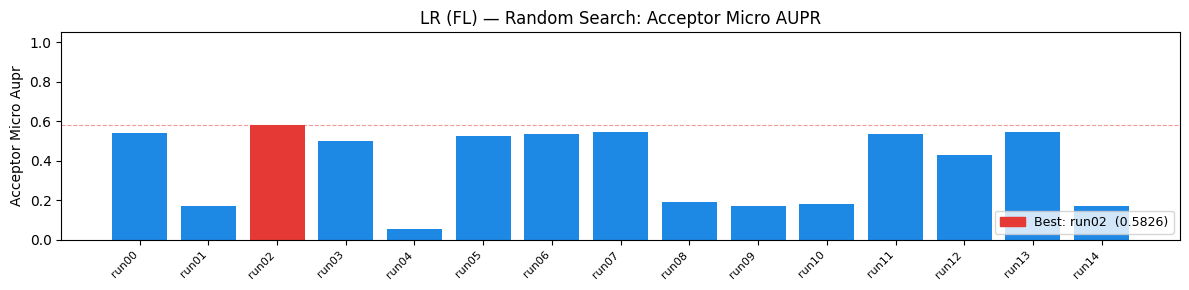

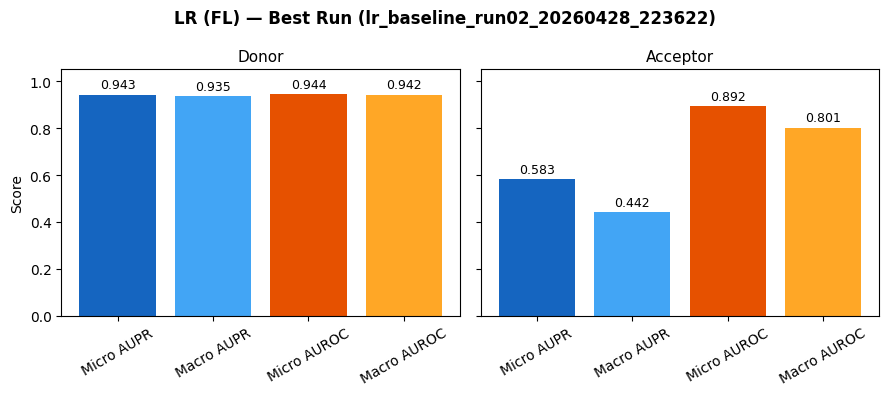

In [ ]:
# Identify the best run, plot the full random search summary, then plot its 4 metrics across both tasks
best_lr_fl = pf.find_best_run(lr_fl_df)
print(f"Best run:           {best_lr_fl['run_tag']}")
print(f"Acceptor micro AUPR: {best_lr_fl['acceptor_micro_aupr']:.4f}")
print(f"Donor   micro AUPR:  {best_lr_fl['donor_micro_aupr']:.4f}")
print(f"Params:              {best_lr_fl['params']}")

fig = pf.plot_search_summary(lr_fl_df, title="LR (FL) — Random Search: Acceptor Micro AUPR")
plt.show()

donor_vals    = {m: best_lr_fl[f"donor_{m}"]    for m in pf.METRIC_COLS}
acceptor_vals = {m: best_lr_fl[f"acceptor_{m}"] for m in pf.METRIC_COLS}
fig = pf.plot_best_run_metrics(
    donor_vals, acceptor_vals,
    title=f"LR (FL) — Best Run ({best_lr_fl['run_tag']})",
)
plt.show()

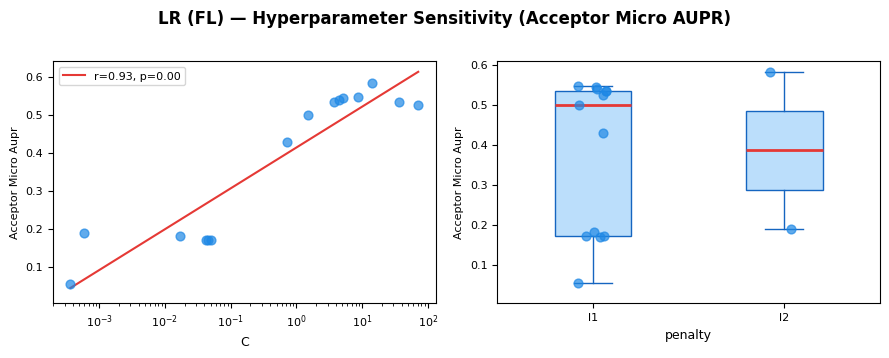

In [ ]:
#Plot Hyperparameters
fig = pf.plot_hyperparam_scatter(
    lr_fl_df,
    param_keys         = ["C", "penalty"],
    metric             = "acceptor_micro_aupr",
    log_scale_params   = ["C"],
    categorical_params = ["penalty"],
    title              = "LR (FL) — Hyperparameter Sensitivity (Acceptor Micro AUPR)",
    ncols              = 2,
)
plt.show()

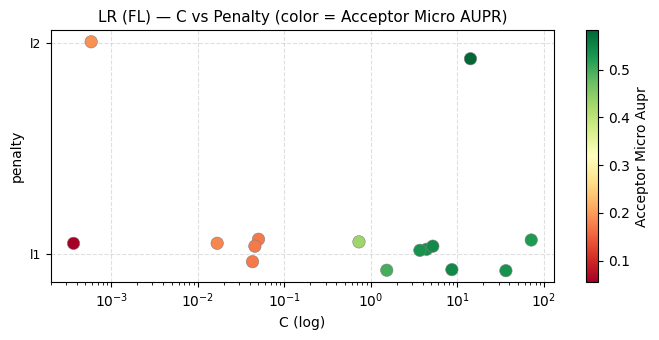

In [ ]:
#Plot hyperparameter for interaction
fig = pf.plot_hyperparam_interaction(
    lr_fl_df,
    x_key="C", y_key="penalty",
    x_log=True, y_categorical=True,
    title="LR (FL) — C vs Penalty (color = Acceptor Micro AUPR)",
)
plt.show()

###3.2: Logistic Regression, Last Layer Embeddings

In [ ]:
# Load the 15 runs in the random search dataset
lr_ll_df = pf.load_random_search_results(RESULTS_DIR, "lr_embedding_baseline")

RS_RUNS_LR_LL = [
    "lr_embedding_baseline_run00_20260428_231845",
    "lr_embedding_baseline_run01_20260428_232033",
    "lr_embedding_baseline_run02_20260428_232050",
    "lr_embedding_baseline_run03_20260428_232137",
    "lr_embedding_baseline_run04_20260428_232156",
    "lr_embedding_baseline_run05_20260428_232210",
    "lr_embedding_baseline_run06_20260428_232245",
    "lr_embedding_baseline_run07_20260428_232305",
    "lr_embedding_baseline_run08_20260428_232327",
    "lr_embedding_baseline_run09_20260428_232345",
    "lr_embedding_baseline_run10_20260428_232402",
    "lr_embedding_baseline_run11_20260428_232418",
    "lr_embedding_baseline_run12_20260428_232446",
    "lr_embedding_baseline_run13_20260428_232505",
    "lr_embedding_baseline_run14_20260428_232527",
]

# Load all LR Last Layer Embeddings (LL) random search runs and display metrics sorted by acceptor micro AUPR
lr_ll_df = lr_ll_df[lr_ll_df["run_tag"].isin(RS_RUNS_LR_LL)].reset_index(drop=True)
print(f"LR (LL) — RS runs: {len(lr_ll_df)}")

display_cols = [
    "run_tag",
    "donor_micro_aupr",  "acceptor_micro_aupr",
    "donor_macro_aupr",  "acceptor_macro_aupr",
    "donor_micro_auroc", "acceptor_micro_auroc",
]
#display(
#    lr_ll_df[display_cols]
#    .sort_values("acceptor_micro_aupr", ascending=False)
#    .reset_index(drop=True)
#)

LR (LL) — RS runs: 15


Best run:           lr_embedding_baseline_run02_20260428_232050
Acceptor micro AUPR: 0.7015
Donor   micro AUPR:  0.9604
Params:              {'C': 14.17710381, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'liblinear', 'tol': 1e-06}


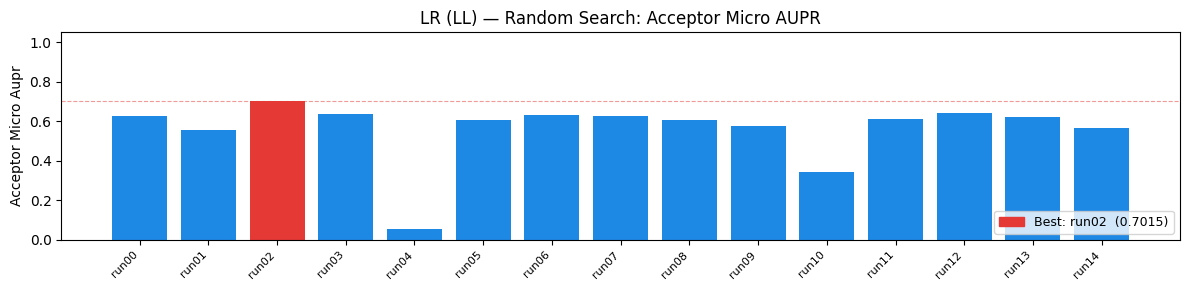

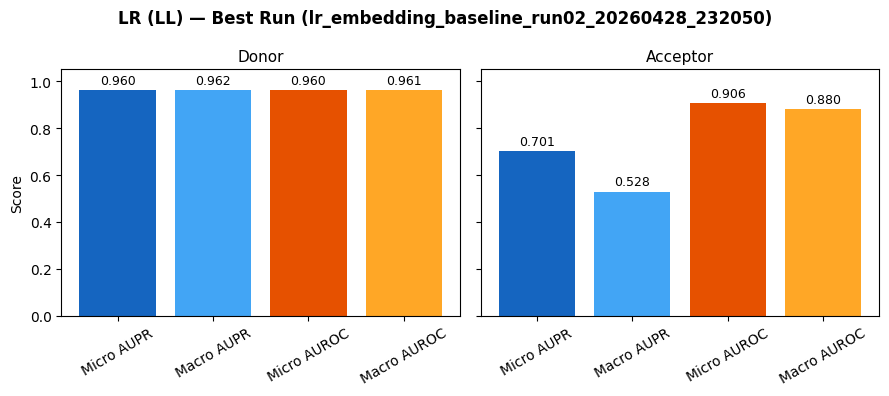

In [ ]:
# Identify the best run, plot the full random search summary, then plot its 4 metrics across both tasks
best_lr_ll = pf.find_best_run(lr_ll_df)
print(f"Best run:           {best_lr_ll['run_tag']}")
print(f"Acceptor micro AUPR: {best_lr_ll['acceptor_micro_aupr']:.4f}")
print(f"Donor   micro AUPR:  {best_lr_ll['donor_micro_aupr']:.4f}")
print(f"Params:              {best_lr_ll['params']}")

fig = pf.plot_search_summary(lr_ll_df, title="LR (LL) — Random Search: Acceptor Micro AUPR")
plt.show()

donor_vals    = {m: best_lr_ll[f"donor_{m}"]    for m in pf.METRIC_COLS}
acceptor_vals = {m: best_lr_ll[f"acceptor_{m}"] for m in pf.METRIC_COLS}
fig = pf.plot_best_run_metrics(
    donor_vals, acceptor_vals,
    title=f"LR (LL) — Best Run ({best_lr_ll['run_tag']})",
)
plt.show()

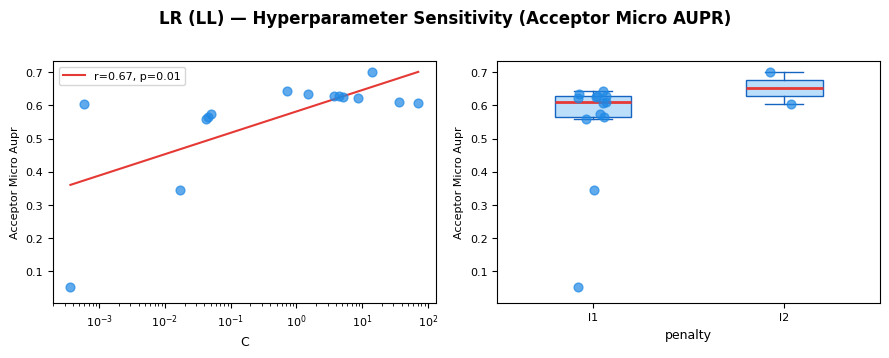

In [ ]:
#Hyperparameter Plotting
fig = pf.plot_hyperparam_scatter(
    lr_ll_df,
    param_keys         = ["C", "penalty"],
    metric             = "acceptor_micro_aupr",
    log_scale_params   = ["C"],
    categorical_params = ["penalty"],
    title              = "LR (LL) — Hyperparameter Sensitivity (Acceptor Micro AUPR)",
    ncols              = 2,
)
plt.show()



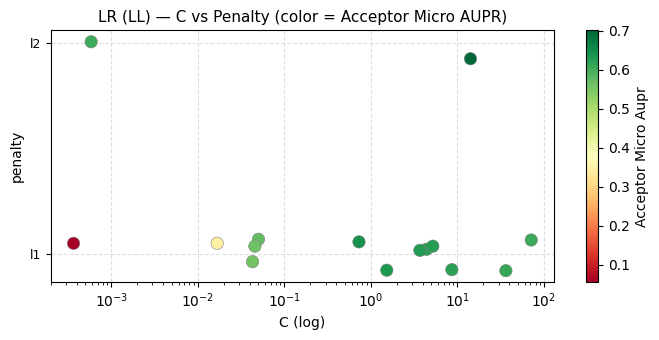

In [ ]:
#PLOT TO SEE IF THERE ARE OBVIOUS INTERACTIONS
fig = pf.plot_hyperparam_interaction(
    lr_ll_df,
    x_key         = "C",
    y_key         = "penalty",
    x_log         = True,
    y_categorical = True,
    title         = "LR (LL) — C vs Penalty (color = Acceptor Micro AUPR)",
)
plt.show()

###3.3: MLP, Function Logits

In [ ]:
# Load the 15 runs in the random search dataset
RS_RUNS_MLP_FL = [
    "mlp_baseline_run00_20260429_001255", "mlp_baseline_run01_20260429_002115",
    "mlp_baseline_run02_20260429_003008", "mlp_baseline_run03_20260429_003611",
    "mlp_baseline_run04_20260429_004359", "mlp_baseline_run05_20260429_005101",
    "mlp_baseline_run06_20260429_005633", "mlp_baseline_run07_20260429_010140",
    "mlp_baseline_run08_20260429_011014", "mlp_baseline_run09_20260429_011955",
    "mlp_baseline_run10_20260429_012503", "mlp_baseline_run11_20260429_013511",
    "mlp_baseline_run12_20260429_014302", "mlp_baseline_run13_20260429_014912",
    "mlp_baseline_run14_20260429_015416",
]

mlp_fl_df = pf.load_random_search_results(RESULTS_DIR, "mlp_baseline")
mlp_fl_df = mlp_fl_df[mlp_fl_df["run_tag"].isin(RS_RUNS_MLP_FL)].reset_index(drop=True)
mlp_fl_df.sort_values("acceptor_micro_aupr", ascending=False)

,run_tag,model,donor_micro_aupr,donor_macro_aupr,donor_micro_auroc,donor_macro_auroc,acceptor_micro_aupr,acceptor_macro_aupr,acceptor_micro_auroc,acceptor_macro_auroc,params
9,mlp_baseline_run09_20260429_011955,mlp_baseline,0.790244,0.798522,0.751997,0.764123,0.259230,0.239719,0.782110,0.730338,"{'batch_size': 16, 'dropout': 0.5, 'early_stop..."
10,mlp_baseline_run10_20260429_012503,mlp_baseline,0.919855,0.924315,0.910292,0.920339,0.229924,0.240908,0.768579,0.734483,"{'batch_size': 16, 'dropout': 0.5, 'early_stop..."
6,mlp_baseline_run06_20260429_005633,mlp_baseline,0.874852,0.876375,0.860971,0.866479,0.218966,0.220902,0.744010,0.689190,"{'batch_size': 16, 'dropout': 0.1, 'early_stop..."
13,mlp_baseline_run13_20260429_014912,mlp_baseline,0.913749,0.902743,0.904433,0.902366,0.209731,0.202994,0.749074,0.700171,"{'batch_size': 16, 'dropout': 0.2, 'early_stop..."
5,mlp_baseline_run05_20260429_005101,mlp_baseline,0.902618,0.899100,0.912877,0.913364,0.185370,0.178380,0.717258,0.636627,"{'batch_size': 16, 'dropout': 0.1, 'early_stop..."
4,mlp_baseline_run04_20260429_004359,mlp_baseline,0.911043,0.916075,0.904238,0.914738,0.169370,0.139132,0.695473,0.649088,"{'batch_size': 16, 'dropout': 0.1, 'early_stop..."
14,mlp_baseline_run14_20260429_015416,mlp_baseline,0.847625,0.871685,0.843402,0.865336,0.130080,0.130871,0.703658,0.658807,"{'batch_size': 16, 'dropout': 0.2, 'early_stop..."
7,mlp_baseline_run07_20260429_010140,mlp_baseline,0.857129,0.881089,0.860559,0.879174,0.126825,0.122851,0.683719,0.645825,"{'batch_size': 16, 'dropout': 0.0, 'early_stop..."
8,mlp_baseline_run08_20260429_011014,mlp_baseline,0.874207,0.885316,0.867249,0.883689,0.119462,0.110863,0.695197,0.626020,"{'batch_size': 16, 'dropout': 0.2, 'early_stop..."
3,mlp_baseline_run03_20260429_003611,mlp_baseline,0.876160,0.885075,0.865961,0.882832,0.116212,0.125379,0.704474,0.634753,"{'batch_size': 16, 'dropout': 0.1, 'early_stop..."


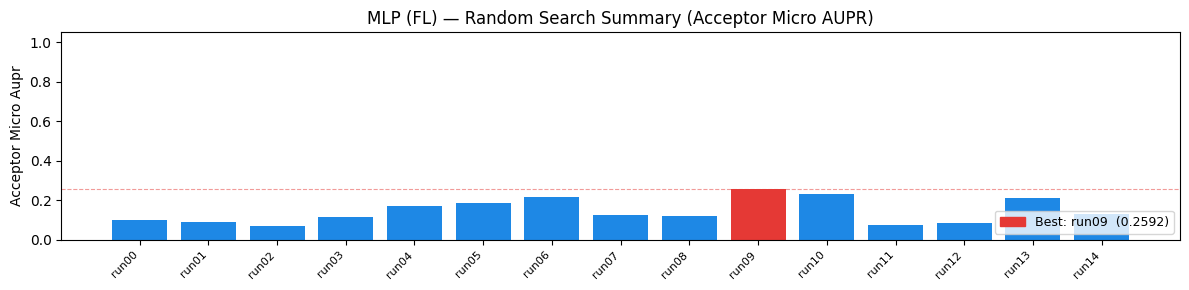

Best run: mlp_baseline_run09_20260429_011955
Params:   {'batch_size': 16, 'dropout': 0.5, 'early_stopping_patience': 10, 'epochs': 500, 'hidden_dim': 512, 'learning_rate': 0.00079574, 'random_seed': 1, 'weight_decay': 0.0}
Donor    micro_aupr = 0.7902
Acceptor micro_aupr = 0.2592


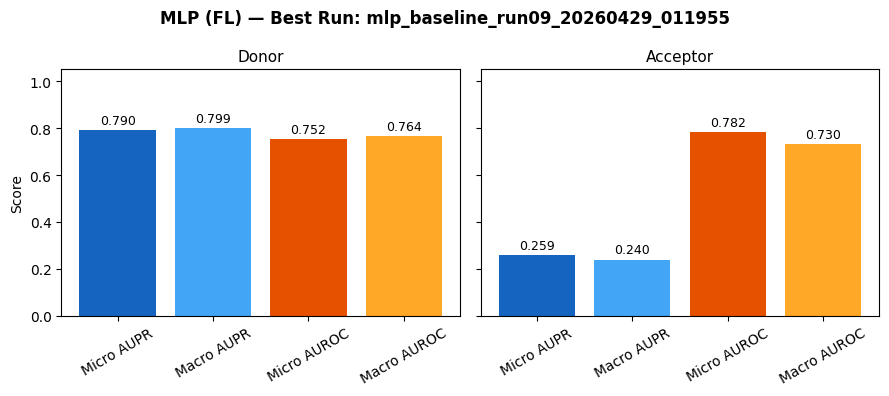

In [ ]:
#PLOT GENERAL STATS
importlib.reload(pf)

fig = pf.plot_search_summary(
    mlp_fl_df,
    metric = "acceptor_micro_aupr",
    title  = "MLP (FL) — Random Search Summary (Acceptor Micro AUPR)",
)
plt.show()

best_mlp_fl = pf.find_best_run(mlp_fl_df)
print(f"Best run: {best_mlp_fl['run_tag']}")
print(f"Params:   {best_mlp_fl['params']}")
print(f"Donor    micro_aupr = {best_mlp_fl['donor_micro_aupr']:.4f}")
print(f"Acceptor micro_aupr = {best_mlp_fl['acceptor_micro_aupr']:.4f}")

fig = pf.plot_best_run_metrics(
    donor_vals    = {m: best_mlp_fl[f"donor_{m}"]    for m in pf.METRIC_COLS},
    acceptor_vals = {m: best_mlp_fl[f"acceptor_{m}"] for m in pf.METRIC_COLS},
    title         = f"MLP (FL) — Best Run: {best_mlp_fl['run_tag']}",
)
plt.show()

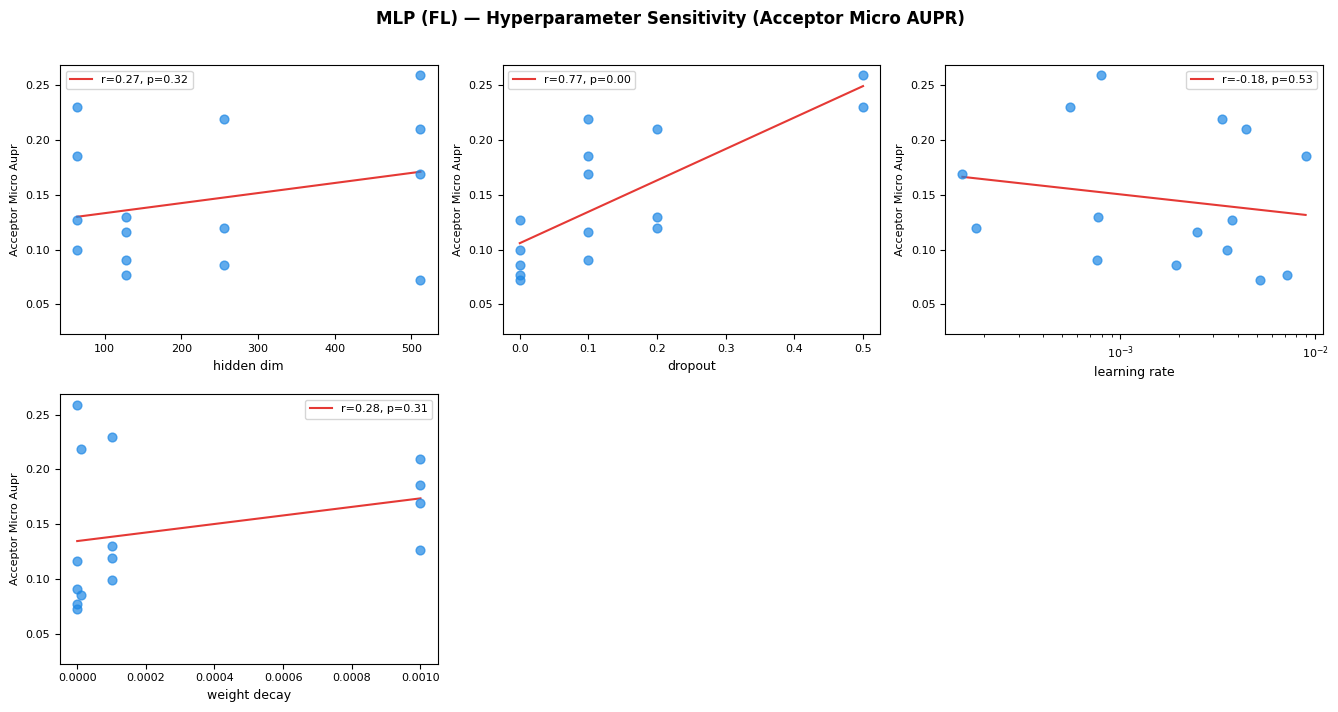

In [ ]:
#PLOT HYPERPARAMETERS
fig = pf.plot_hyperparam_scatter(
    mlp_fl_df,
    param_keys         = ["hidden_dim", "dropout", "learning_rate", "weight_decay", "pooling"],
    metric             = "acceptor_micro_aupr",
    log_scale_params   = ["learning_rate"],
    categorical_params = ["pooling"],
    title              = "MLP (FL) — Hyperparameter Sensitivity (Acceptor Micro AUPR)",
    ncols              = 3,
)
plt.show()



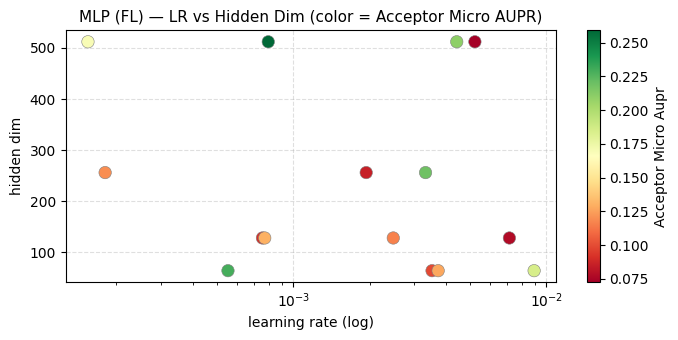

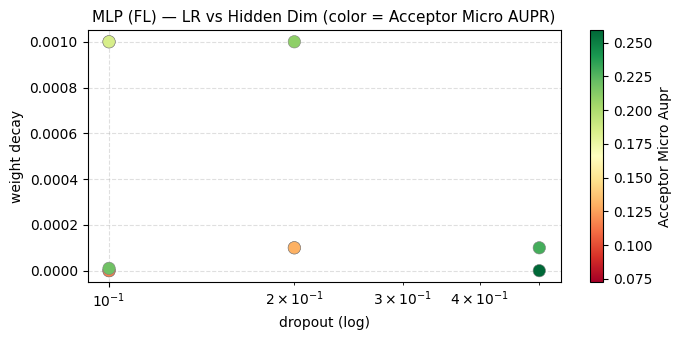

In [ ]:
#PLOT TO OBSERVE OBVIOUS INTERACTIONS
fig = pf.plot_hyperparam_interaction(
    mlp_fl_df,
    x_key  = "learning_rate",
    y_key  = "hidden_dim",
    x_log  = True,
    metric = "acceptor_micro_aupr",
    title  = "MLP (FL) — LR vs Hidden Dim (color = Acceptor Micro AUPR)",
)
plt.show()

fig = pf.plot_hyperparam_interaction(
    mlp_fl_df,
    x_key  = "dropout",
    y_key  = "weight_decay",
    x_log  = True,
    metric = "acceptor_micro_aupr",
    title  = "MLP (FL) — LR vs Hidden Dim (color = Acceptor Micro AUPR)",
)
plt.show()

###3.4: MLP, Last Layer Embeddings

In [ ]:
#DESIGNATE THE 15 RUNS
RS_RUNS_MLP_LL = [
    "mlp_embedding_baseline_run00_20260429_001722", "mlp_embedding_baseline_run01_20260429_002103",
    "mlp_embedding_baseline_run02_20260429_002608", "mlp_embedding_baseline_run03_20260429_002858",
    "mlp_embedding_baseline_run04_20260429_003227", "mlp_embedding_baseline_run05_20260429_003527",
    "mlp_embedding_baseline_run06_20260429_003827", "mlp_embedding_baseline_run07_20260429_004116",
    "mlp_embedding_baseline_run08_20260429_004541", "mlp_embedding_baseline_run09_20260429_005549",
    "mlp_embedding_baseline_run10_20260429_005855", "mlp_embedding_baseline_run11_20260429_010317",
    "mlp_embedding_baseline_run12_20260429_010607", "mlp_embedding_baseline_run13_20260429_010936",
    "mlp_embedding_baseline_run14_20260429_011232",
]

mlp_ll_df = pf.load_random_search_results(RESULTS_DIR, "mlp_embedding_baseline")
mlp_ll_df = mlp_ll_df[mlp_ll_df["run_tag"].isin(RS_RUNS_MLP_LL)].reset_index(drop=True)
mlp_ll_df.sort_values("acceptor_micro_aupr", ascending=False)

,run_tag,model,donor_micro_aupr,donor_macro_aupr,donor_micro_auroc,donor_macro_auroc,acceptor_micro_aupr,acceptor_macro_aupr,acceptor_micro_auroc,acceptor_macro_auroc,params
1,mlp_embedding_baseline_run01_20260429_002103,mlp_embedding_baseline,0.946269,0.944497,0.943033,0.942905,0.502296,0.403073,0.885988,0.835783,"{'batch_size': 16, 'dropout': 0.1, 'early_stop..."
14,mlp_embedding_baseline_run14_20260429_011232,mlp_embedding_baseline,0.946118,0.944386,0.941505,0.941770,0.499738,0.401540,0.885814,0.835437,"{'batch_size': 16, 'dropout': 0.2, 'early_stop..."
0,mlp_embedding_baseline_run00_20260429_001722,mlp_embedding_baseline,0.957750,0.955846,0.954901,0.954780,0.480646,0.402250,0.875102,0.830384,"{'batch_size': 16, 'dropout': 0.0, 'early_stop..."
12,mlp_embedding_baseline_run12_20260429_010607,mlp_embedding_baseline,0.960719,0.960061,0.958931,0.958795,0.477618,0.393446,0.874949,0.835178,"{'batch_size': 16, 'dropout': 0.0, 'early_stop..."
3,mlp_embedding_baseline_run03_20260429_002858,mlp_embedding_baseline,0.954882,0.954009,0.952054,0.952311,0.476462,0.376982,0.871143,0.821448,"{'batch_size': 16, 'dropout': 0.1, 'early_stop..."
8,mlp_embedding_baseline_run08_20260429_004541,mlp_embedding_baseline,0.953009,0.949312,0.950772,0.949017,0.470001,0.382044,0.876335,0.828244,"{'batch_size': 16, 'dropout': 0.2, 'early_stop..."
7,mlp_embedding_baseline_run07_20260429_004116,mlp_embedding_baseline,0.961557,0.962404,0.959314,0.960848,0.458818,0.390882,0.876716,0.827501,"{'batch_size': 16, 'dropout': 0.0, 'early_stop..."
11,mlp_embedding_baseline_run11_20260429_010317,mlp_embedding_baseline,0.946574,0.944606,0.939527,0.938245,0.438604,0.373347,0.867285,0.820290,"{'batch_size': 16, 'dropout': 0.0, 'early_stop..."
10,mlp_embedding_baseline_run10_20260429_005855,mlp_embedding_baseline,0.938392,0.937856,0.939721,0.941196,0.436227,0.387136,0.881736,0.829420,"{'batch_size': 16, 'dropout': 0.5, 'early_stop..."
2,mlp_embedding_baseline_run02_20260429_002608,mlp_embedding_baseline,0.949995,0.950135,0.946251,0.948269,0.388464,0.387401,0.861387,0.830304,"{'batch_size': 16, 'dropout': 0.0, 'early_stop..."


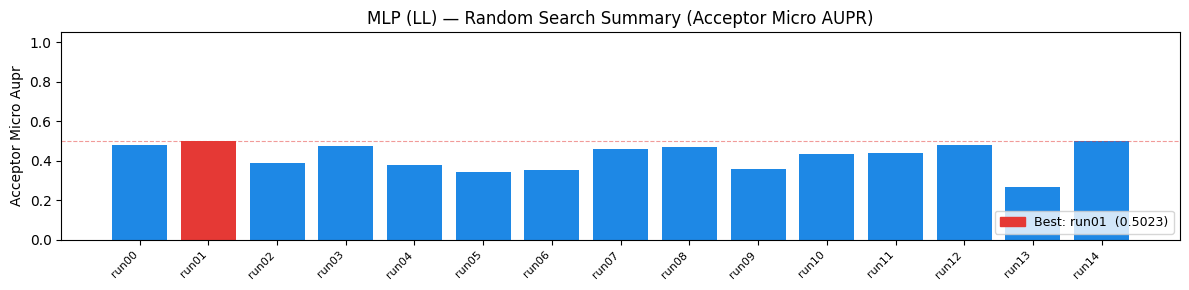

Best run: mlp_embedding_baseline_run01_20260429_002103
Params:   {'batch_size': 16, 'dropout': 0.1, 'early_stopping_patience': 10, 'epochs': 500, 'hidden_dim': 128, 'learning_rate': 0.00075467, 'pooling': 'mean', 'random_seed': 1, 'weight_decay': 0.0}
Donor    micro_aupr = 0.9463
Acceptor micro_aupr = 0.5023


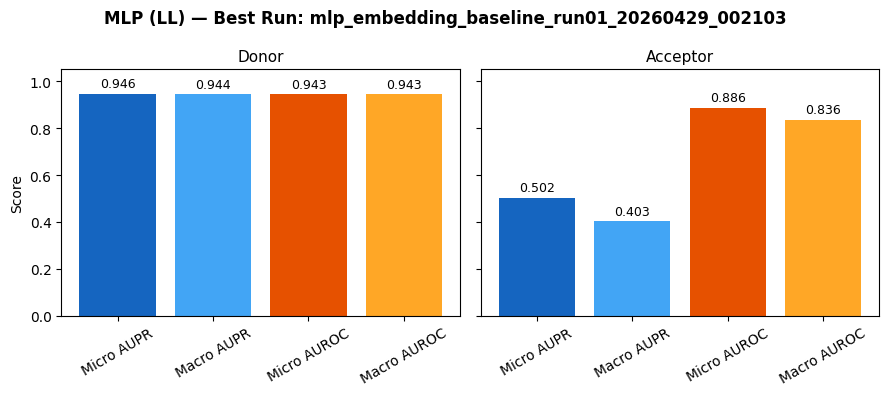

In [ ]:
#PLOT RUN STATS
importlib.reload(pf)

fig = pf.plot_search_summary(
    mlp_ll_df,
    metric = "acceptor_micro_aupr",
    title  = "MLP (LL) — Random Search Summary (Acceptor Micro AUPR)",
)
plt.show()

best_mlp_ll = pf.find_best_run(mlp_ll_df)
print(f"Best run: {best_mlp_ll['run_tag']}")
print(f"Params:   {best_mlp_ll['params']}")
print(f"Donor    micro_aupr = {best_mlp_ll['donor_micro_aupr']:.4f}")
print(f"Acceptor micro_aupr = {best_mlp_ll['acceptor_micro_aupr']:.4f}")

fig = pf.plot_best_run_metrics(
    donor_vals    = {m: best_mlp_ll[f"donor_{m}"]    for m in pf.METRIC_COLS},
    acceptor_vals = {m: best_mlp_ll[f"acceptor_{m}"] for m in pf.METRIC_COLS},
    title         = f"MLP (LL) — Best Run: {best_mlp_ll['run_tag']}",
)
plt.show()

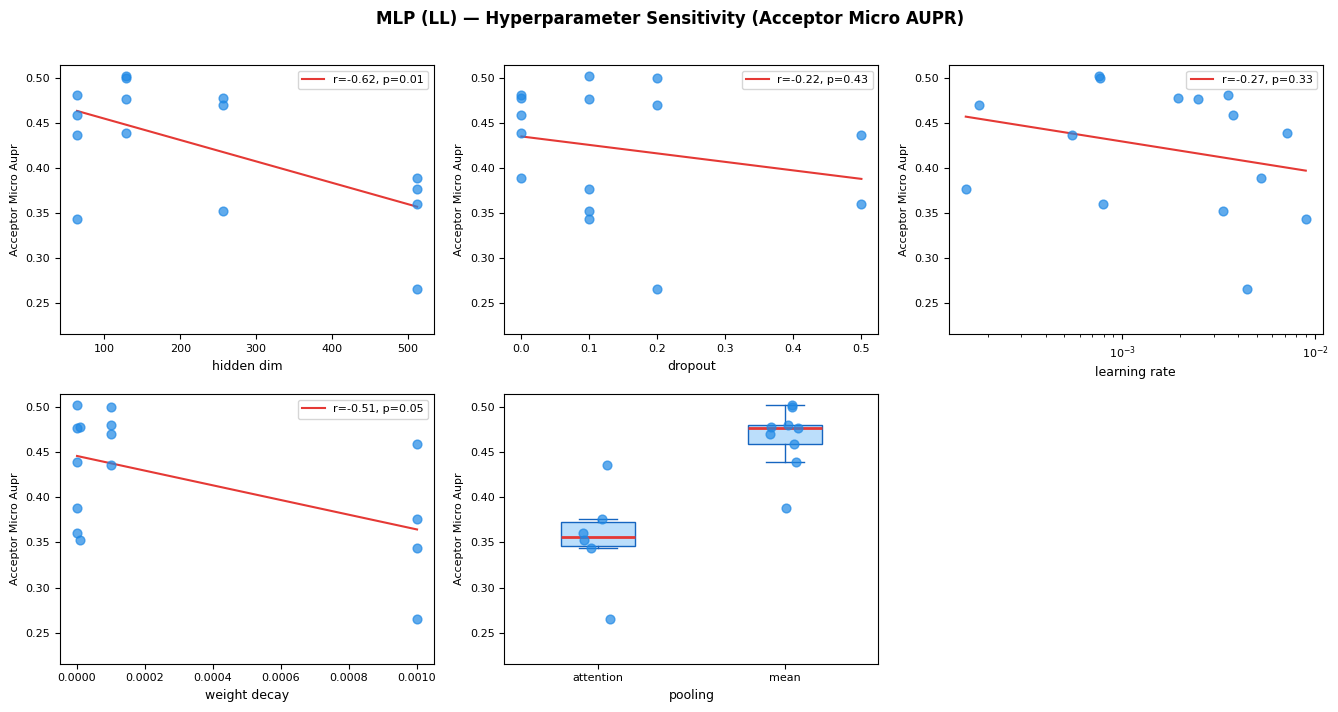

In [ ]:
#PLOT HYPERPARAMETERS
fig = pf.plot_hyperparam_scatter(
    mlp_ll_df,
    param_keys         = ["hidden_dim", "dropout", "learning_rate", "weight_decay", "pooling"],
    metric             = "acceptor_micro_aupr",
    log_scale_params   = ["learning_rate"],
    categorical_params = ["pooling"],
    title              = "MLP (LL) — Hyperparameter Sensitivity (Acceptor Micro AUPR)",
    ncols              = 3,
)
plt.show()



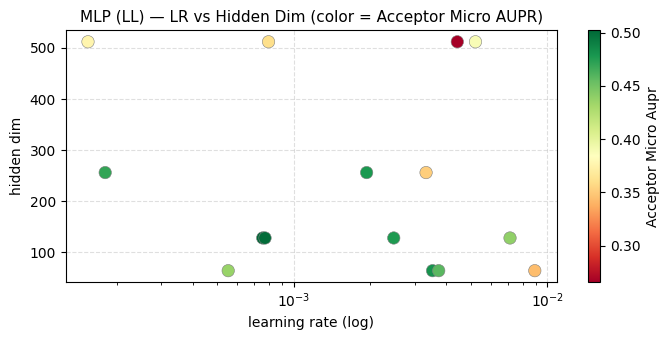

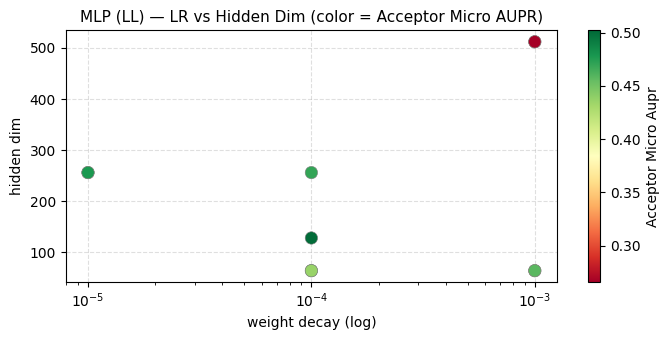

In [ ]:
#PLOT TO FIND OBVIOUS INTERACTIONS
fig = pf.plot_hyperparam_interaction(
    mlp_ll_df,
    x_key  = "learning_rate",
    y_key  = "hidden_dim",
    x_log  = True,
    metric = "acceptor_micro_aupr",
    title  = "MLP (LL) — LR vs Hidden Dim (color = Acceptor Micro AUPR)",
)
plt.show()

fig = pf.plot_hyperparam_interaction(
    mlp_ll_df,
    x_key  = "weight_decay",
    y_key  = "hidden_dim",
    x_log  = True,
    metric = "acceptor_micro_aupr",
    title  = "MLP (LL) — LR vs Hidden Dim (color = Acceptor Micro AUPR)",
)
plt.show()

###3.5: Soft Function Logit Decoder, Funciton Logits

In [ ]:
#DESIGNATE 15 RUNS
RS_RUNS_SFD_FL = [
    "soft_func_logit_decoder_run00_20260429_143119",
    "soft_func_logit_decoder_run01_20260429_145657",
    "soft_func_logit_decoder_run02_20260429_151538",
    "soft_func_logit_decoder_run03_20260429_153051",
    "soft_func_logit_decoder_run04_20260429_154924",
    "soft_func_logit_decoder_run05_20260429_160513",
    "soft_func_logit_decoder_run06_20260429_162438",
    "soft_func_logit_decoder_run07_20260429_163933",
    "soft_func_logit_decoder_run08_20260429_165455",
    "soft_func_logit_decoder_run09_20260429_171004",
    "soft_func_logit_decoder_run10_20260429_173142",
    "soft_func_logit_decoder_run11_20260429_175832",
    "soft_func_logit_decoder_run12_20260429_181949",
    "soft_func_logit_decoder_run13_20260429_183652",
    "soft_func_logit_decoder_run14_20260429_185414",
]

importlib.reload(pf)
sfd_fl_df = pf.load_random_search_results(RESULTS_DIR, "soft_func_logit_decoder")
sfd_fl_df = sfd_fl_df[sfd_fl_df["run_tag"].isin(RS_RUNS_SFD_FL)].reset_index(drop=True)
sfd_fl_df.sort_values("acceptor_micro_aupr", ascending=False)

,run_tag,model,donor_micro_aupr,donor_macro_aupr,donor_micro_auroc,donor_macro_auroc,acceptor_micro_aupr,acceptor_macro_aupr,acceptor_micro_auroc,acceptor_macro_auroc,params
4,soft_func_logit_decoder_run04_20260429_154924,soft_func_logit_decoder,0.958324,0.945987,0.948090,0.946042,0.551126,0.422712,0.897478,0.851511,"{'batch_size': 8, 'd_model': 256, 'dropout': 0..."
8,soft_func_logit_decoder_run08_20260429_165455,soft_func_logit_decoder,0.924347,0.926406,0.930896,0.931207,0.513063,0.428965,0.867150,0.827851,"{'batch_size': 8, 'd_model': 256, 'dropout': 0..."
1,soft_func_logit_decoder_run01_20260429_145657,soft_func_logit_decoder,0.906839,0.901880,0.905774,0.903917,0.441644,0.357653,0.859694,0.809037,"{'batch_size': 8, 'd_model': 64, 'dropout': 0...."
9,soft_func_logit_decoder_run09_20260429_171004,soft_func_logit_decoder,0.897660,0.886360,0.896551,0.895187,0.342674,0.308296,0.849908,0.790873,"{'batch_size': 8, 'd_model': 128, 'dropout': 0..."
6,soft_func_logit_decoder_run06_20260429_162438,soft_func_logit_decoder,0.926098,0.924732,0.925711,0.923522,0.259866,0.278450,0.831022,0.772042,"{'batch_size': 8, 'd_model': 128, 'dropout': 0..."
0,soft_func_logit_decoder_run00_20260429_143119,soft_func_logit_decoder,0.914155,0.915398,0.909970,0.907730,0.198140,0.215351,0.771519,0.771937,"{'batch_size': 8, 'd_model': 256, 'dropout': 0..."
7,soft_func_logit_decoder_run07_20260429_163933,soft_func_logit_decoder,0.921615,0.907851,0.921508,0.921446,0.176041,0.184809,0.745082,0.712771,"{'batch_size': 8, 'd_model': 64, 'dropout': 0...."
12,soft_func_logit_decoder_run12_20260429_181949,soft_func_logit_decoder,0.911208,0.881439,0.899631,0.899749,0.106719,0.144966,0.588644,0.587630,"{'batch_size': 8, 'd_model': 64, 'dropout': 0...."
10,soft_func_logit_decoder_run10_20260429_173142,soft_func_logit_decoder,0.608422,0.637823,0.540709,0.556237,0.090536,0.111985,0.573579,0.612646,"{'batch_size': 8, 'd_model': 256, 'dropout': 0..."
5,soft_func_logit_decoder_run05_20260429_160513,soft_func_logit_decoder,0.520761,0.525800,0.470031,0.482273,0.082780,0.066747,0.532124,0.511852,"{'batch_size': 8, 'd_model': 64, 'dropout': 0...."


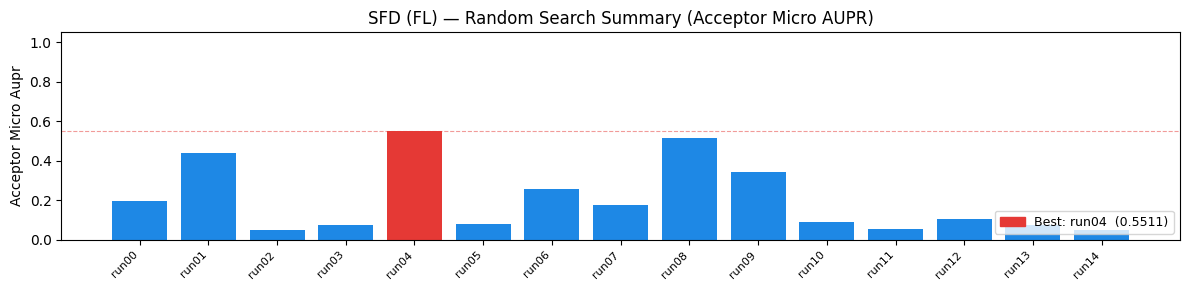

Best run: soft_func_logit_decoder_run04_20260429_154924
Params:   {'batch_size': 8, 'd_model': 256, 'dropout': 0.3, 'epochs': 100, 'learning_rate': 0.00014455, 'n_heads': 8, 'n_layers': 1, 'pooling': 'attention', 'random_seed': 1, 'temperature': 5.0, 'weight_decay': 0.0001}
Donor    micro_aupr = 0.9583
Acceptor micro_aupr = 0.5511


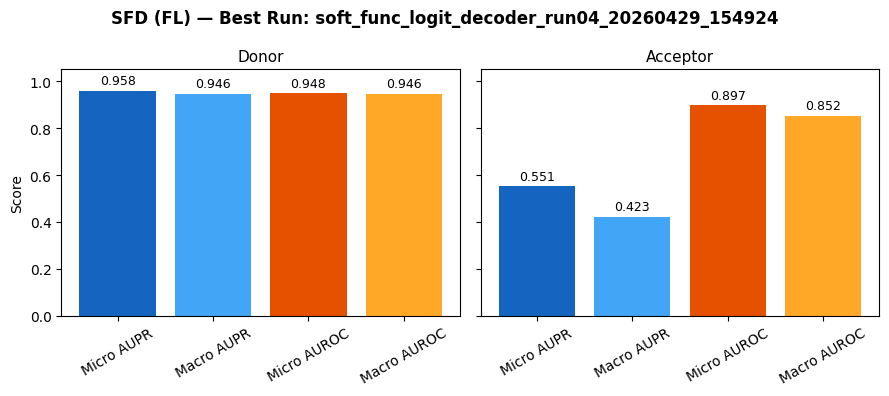

In [ ]:
#GENERAL RUN STATS
fig = pf.plot_search_summary(
    sfd_fl_df,
    metric = "acceptor_micro_aupr",
    title  = "SFD (FL) — Random Search Summary (Acceptor Micro AUPR)",
)
plt.show()

best_sfd_fl = pf.find_best_run(sfd_fl_df)
print(f"Best run: {best_sfd_fl['run_tag']}")
print(f"Params:   {best_sfd_fl['params']}")
print(f"Donor    micro_aupr = {best_sfd_fl['donor_micro_aupr']:.4f}")
print(f"Acceptor micro_aupr = {best_sfd_fl['acceptor_micro_aupr']:.4f}")

fig = pf.plot_best_run_metrics(
    donor_vals    = {m: best_sfd_fl[f"donor_{m}"]    for m in pf.METRIC_COLS},
    acceptor_vals = {m: best_sfd_fl[f"acceptor_{m}"] for m in pf.METRIC_COLS},
    title         = f"SFD (FL) — Best Run: {best_sfd_fl['run_tag']}",
)
plt.show()



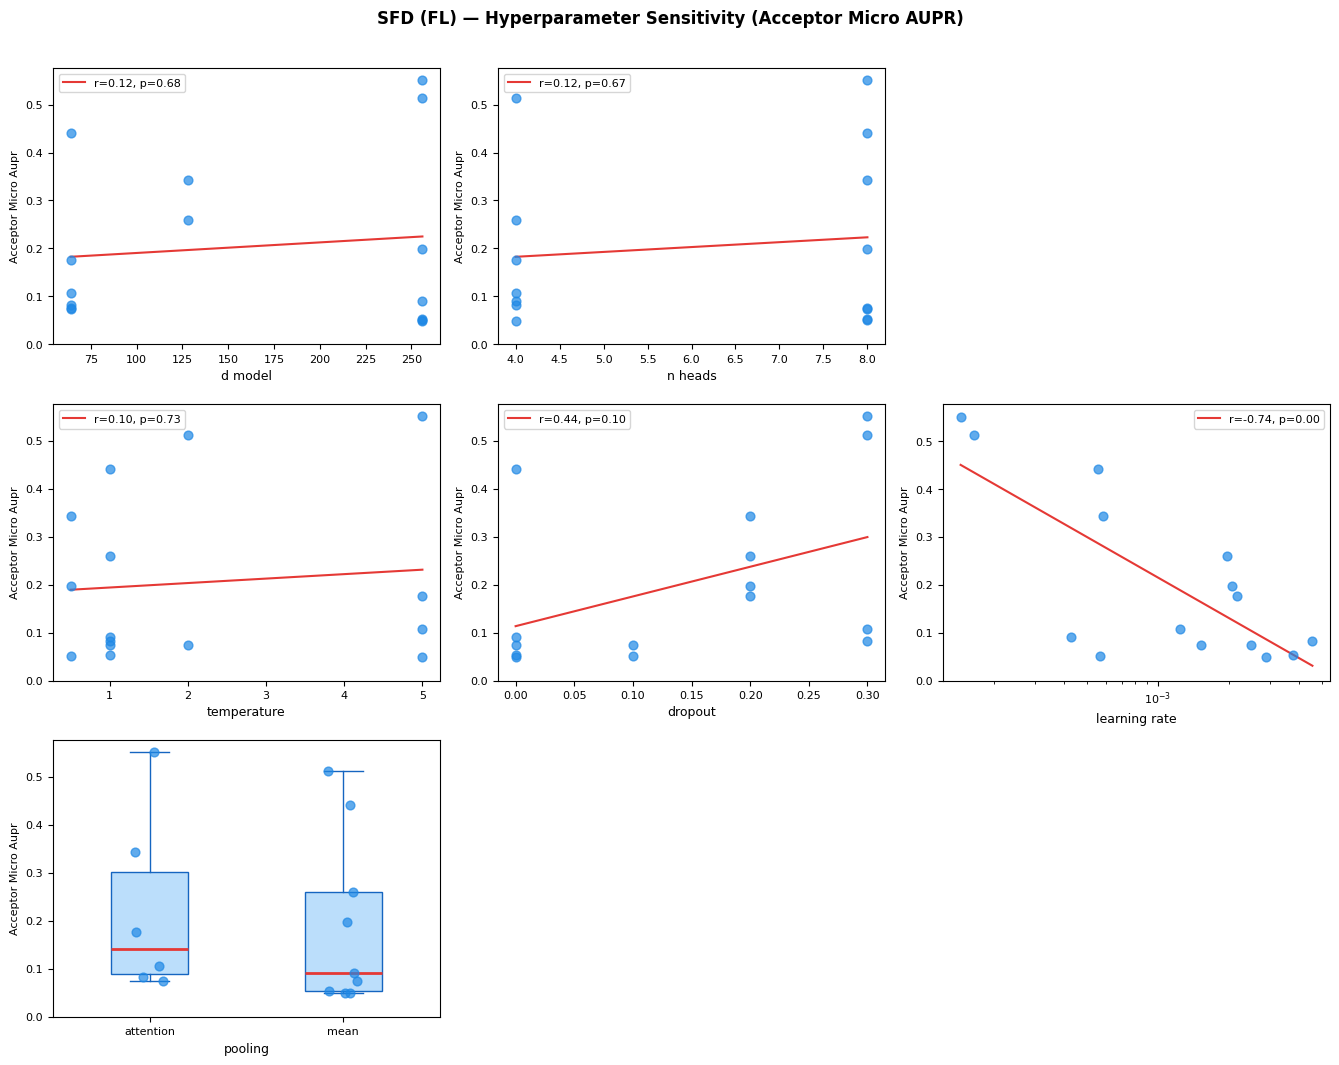

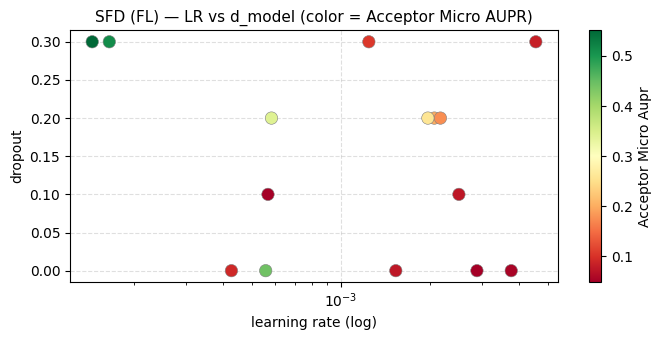

In [ ]:
#PLOT HYPERPARAMETERS AND INTERACTIONS
fig = pf.plot_hyperparam_scatter(
    sfd_fl_df,
    param_keys         = ["d_model", "n_heads", "num_layers", "temperature", "dropout", "learning_rate", "pooling"],
    metric             = "acceptor_micro_aupr",
    log_scale_params   = ["learning_rate"],
    categorical_params = ["pooling"],
    title              = "SFD (FL) — Hyperparameter Sensitivity (Acceptor Micro AUPR)",
    ncols              = 3,
)
plt.show()

fig = pf.plot_hyperparam_interaction(
    sfd_fl_df,
    x_key         = "learning_rate",
    y_key         = "dropout",
    x_log         = True,
    metric        = "acceptor_micro_aupr",
    title         = "SFD (FL) — LR vs d_model (color = Acceptor Micro AUPR)",
)
plt.show()

###3.6: Transformer, Last Layer Embeddings

In [ ]:
#DESIGNATE RUNS
RS_RUNS_TFM_LL = [
    "embedding_transformer_run00_20260429_123644",
    "embedding_transformer_run01_20260429_125230",
    "embedding_transformer_run02_20260429_130643",
    "embedding_transformer_run03_20260429_141415",
    "embedding_transformer_run04_20260429_150031",
    "embedding_transformer_run05_20260429_154700",
    "embedding_transformer_run06_20260429_155825",
    "embedding_transformer_run07_20260429_170610",
    "embedding_transformer_run08_20260429_175006",
    "embedding_transformer_run09_20260429_185719",
    "embedding_transformer_run10_20260429_190855",
    "embedding_transformer_run11_20260429_210417",
    "embedding_transformer_run12_20260429_214858",
    "embedding_transformer_run13_20260429_220038",
    "embedding_transformer_run14_20260429_223041",
]
importlib.reload(pf)

tfm_ll_df_all = pf.load_random_search_results(
    ML_DIR / "results",
    "embedding_transformer",
    "BAHD"
)

tfm_ll_df = tfm_ll_df_all[
    tfm_ll_df_all["run_tag"].isin(RS_RUNS_TFM_LL)
].reset_index(drop=True)

print(f"Loaded {len(tfm_ll_df)} runs")

best_tfm_ll = pf.find_best_run(tfm_ll_df, key="acceptor_micro_aupr")
print(f"Best run: {best_tfm_ll['run_tag']}")
print(f"  acceptor micro AUPR: {best_tfm_ll['acceptor_micro_aupr']:.4f}")
print(f"  donor   micro AUPR: {best_tfm_ll['donor_micro_aupr']:.4f}")
print(f"  params: {best_tfm_ll['params']}")

Loaded 15 runs
Best run: embedding_transformer_run12_20260429_214858
  acceptor micro AUPR: 0.6298
  donor   micro AUPR: 0.9261
  params: {'batch_size': 8, 'd_model': 256, 'dropout': 0.2, 'epochs': 100, 'learning_rate': 0.00024295, 'n_heads': 4, 'n_layers': 1, 'pooling': 'mean', 'random_seed': 1, 'weight_decay': 0.0001}


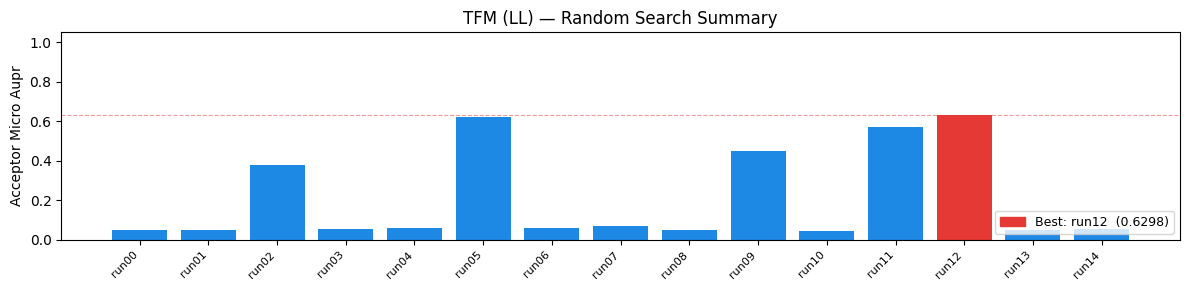

In [ ]:
#RUN STATS
fig = pf.plot_search_summary(
    tfm_ll_df,
    title="TFM (LL) — Random Search Summary"
)
plt.show()

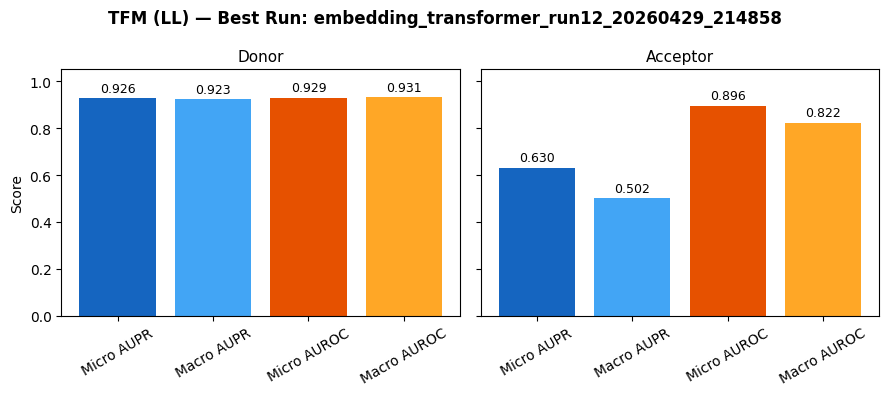

In [ ]:
#RUN STATS
fig = pf.plot_best_run_metrics(
    donor_vals={m: best_tfm_ll[f"donor_{m}"] for m in pf.METRIC_COLS},
    acceptor_vals={m: best_tfm_ll[f"acceptor_{m}"] for m in pf.METRIC_COLS},
    title=f"TFM (LL) — Best Run: {best_tfm_ll['run_tag']}"
)
plt.show()

###3.7: Ridge Classifier

In [ ]:
#DESIGNATE RUNS
RS_RUNS_RIDGE_FL = [
    "ridge_baseline_run00_20260429_212404", "ridge_baseline_run01_20260429_212429",
    "ridge_baseline_run02_20260429_212447", "ridge_baseline_run03_20260429_212509",
    "ridge_baseline_run04_20260429_212528", "ridge_baseline_run05_20260429_212551",
    "ridge_baseline_run06_20260429_212610", "ridge_baseline_run07_20260429_212632",
    "ridge_baseline_run08_20260429_212651", "ridge_baseline_run09_20260429_212710",
    "ridge_baseline_run10_20260429_212732", "ridge_baseline_run11_20260429_212751",
    "ridge_baseline_run12_20260429_212812", "ridge_baseline_run13_20260429_212831",
    "ridge_baseline_run14_20260429_212850",
]

importlib.reload(pf)
ridge_fl_df = pf.load_random_search_results(RESULTS_DIR, "ridge_baseline")
ridge_fl_df = ridge_fl_df[ridge_fl_df["run_tag"].isin(RS_RUNS_RIDGE_FL)].reset_index(drop=True)
ridge_fl_df.sort_values("acceptor_micro_aupr", ascending=False)

,run_tag,model,donor_micro_aupr,donor_macro_aupr,donor_micro_auroc,donor_macro_auroc,acceptor_micro_aupr,acceptor_macro_aupr,acceptor_micro_auroc,acceptor_macro_auroc,params
10,ridge_baseline_run10_20260429_212732,ridge_baseline,0.934625,0.932178,0.940047,0.940697,0.618400,0.522845,0.898901,0.794375,"{'alpha': 0.16779853, 'class_weight': 'balance..."
1,ridge_baseline_run01_20260429_212429,ridge_baseline,0.934823,0.931216,0.941613,0.941338,0.612473,0.518765,0.900845,0.791318,"{'alpha': 0.42980418, 'class_weight': 'balance..."
9,ridge_baseline_run09_20260429_212710,ridge_baseline,0.934413,0.930339,0.941486,0.941058,0.609385,0.515748,0.900737,0.790472,"{'alpha': 0.50386667, 'class_weight': 'balance..."
14,ridge_baseline_run14_20260429_212850,ridge_baseline,0.925341,0.923523,0.935844,0.936587,0.597502,0.514237,0.890991,0.816126,"{'alpha': 0.03748253, 'class_weight': 'balance..."
12,ridge_baseline_run12_20260429_212812,ridge_baseline,0.933047,0.928581,0.930959,0.930753,0.543306,0.471142,0.893933,0.791973,"{'alpha': 7.29777922, 'class_weight': 'balance..."
3,ridge_baseline_run03_20260429_212509,ridge_baseline,0.930260,0.925524,0.927048,0.926721,0.519248,0.458427,0.891693,0.796075,"{'alpha': 15.28298456, 'class_weight': 'balanc..."
6,ridge_baseline_run06_20260429_212610,ridge_baseline,0.928238,0.921835,0.922905,0.922005,0.483558,0.433788,0.888880,0.808401,"{'alpha': 36.88401687, 'class_weight': 'balanc..."
0,ridge_baseline_run00_20260429_212404,ridge_baseline,0.927617,0.921017,0.921774,0.921021,0.475729,0.426876,0.888127,0.811107,"{'alpha': 44.02874347, 'class_weight': 'balanc..."
7,ridge_baseline_run07_20260429_212632,ridge_baseline,0.927418,0.920896,0.920972,0.920450,0.467135,0.421404,0.887289,0.812810,"{'alpha': 52.04581716, 'class_weight': 'balanc..."
13,ridge_baseline_run13_20260429_212831,ridge_baseline,0.926823,0.921358,0.918650,0.918379,0.436241,0.397099,0.884182,0.815907,"{'alpha': 86.41112904, 'class_weight': 'balanc..."


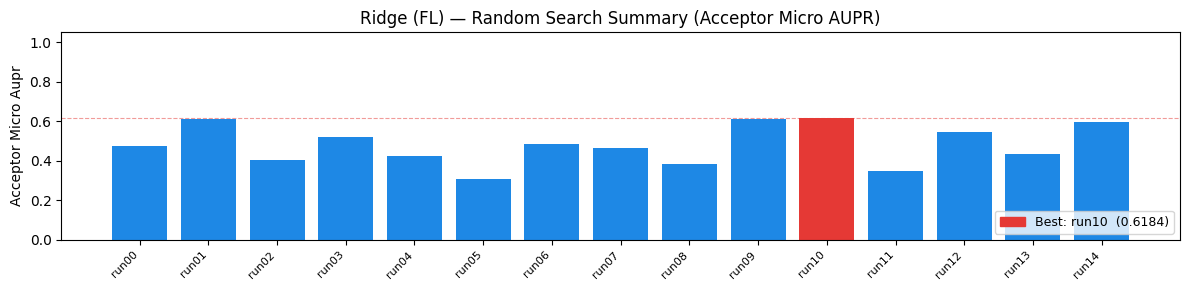

Best run: ridge_baseline_run10_20260429_212732
Params:   {'alpha': 0.16779853, 'class_weight': 'balanced', 'fit_intercept': True}
Donor    micro_aupr = 0.9346
Acceptor micro_aupr = 0.6184


In [ ]:
#RUN STATS
fig = pf.plot_search_summary(
    ridge_fl_df,
    metric = "acceptor_micro_aupr",
    title  = "Ridge (FL) — Random Search Summary (Acceptor Micro AUPR)",
)
plt.show()

best_ridge_fl = pf.find_best_run(ridge_fl_df)
print(f"Best run: {best_ridge_fl['run_tag']}")
print(f"Params:   {best_ridge_fl['params']}")
print(f"Donor    micro_aupr = {best_ridge_fl['donor_micro_aupr']:.4f}")
print(f"Acceptor micro_aupr = {best_ridge_fl['acceptor_micro_aupr']:.4f}")



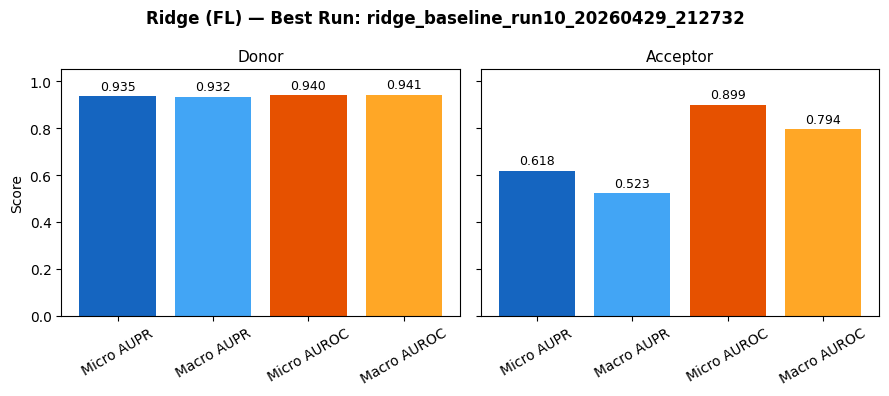

In [ ]:
#RUN STATS
fig = pf.plot_best_run_metrics(
    donor_vals    = {m: best_ridge_fl[f"donor_{m}"]    for m in pf.METRIC_COLS},
    acceptor_vals = {m: best_ridge_fl[f"acceptor_{m}"] for m in pf.METRIC_COLS},
    title         = f"Ridge (FL) — Best Run: {best_ridge_fl['run_tag']}",
)
plt.show()



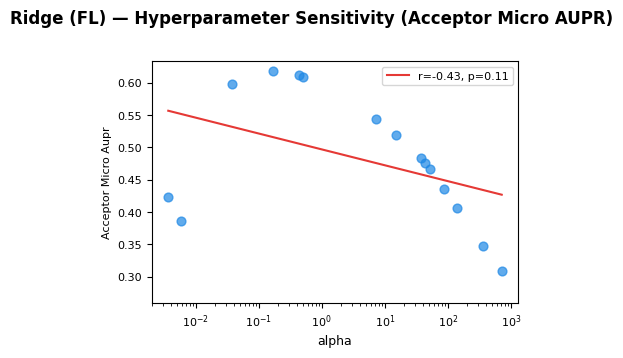

In [ ]:
#PLOT HYPERPARAMETERS
fig = pf.plot_hyperparam_scatter(
    ridge_fl_df,
    param_keys       = ["alpha"],
    metric           = "acceptor_micro_aupr",
    log_scale_params = ["alpha"],
    title            = "Ridge (FL) — Hyperparameter Sensitivity (Acceptor Micro AUPR)",
    ncols            = 1,
)
plt.show()

###3.8: Support Vector Classifier with Radial Basis Function Kernel (SVC_RBF)

In [ ]:
#DESIGNATE RUNS
importlib.reload(pf)

RS_RUNS_SVC_LL = [
    "svc_embedding_baseline_run00_20260430_231951",
    "svc_embedding_baseline_run01_20260430_232020",
    "svc_embedding_baseline_run02_20260430_232045",
    "svc_embedding_baseline_run03_20260430_232108",
    "svc_embedding_baseline_run04_20260430_232135",
    "svc_embedding_baseline_run05_20260430_232200",
    "svc_embedding_baseline_run06_20260430_232230",
    "svc_embedding_baseline_run07_20260430_232247",
    "svc_embedding_baseline_run08_20260430_232310",
    "svc_embedding_baseline_run09_20260430_232336",
    "svc_embedding_baseline_run10_20260430_232356",
    "svc_embedding_baseline_run11_20260430_232414",
    "svc_embedding_baseline_run12_20260430_232438",
    "svc_embedding_baseline_run13_20260430_232503",
    "svc_embedding_baseline_run14_20260430_232527",
]

svc_ll_df = pf.load_random_search_results(
    ML_DIR / "results", "svc_embedding_baseline", "BAHD"
)
svc_ll_df = svc_ll_df[
    svc_ll_df["run_tag"].isin(RS_RUNS_SVC_LL)
].reset_index(drop=True)

print(f"Loaded {len(svc_ll_df)} runs")

best_svc_ll = pf.find_best_run(svc_ll_df, key="acceptor_micro_aupr")
print(f"\nBest SVC (LL) run: {best_svc_ll['run_tag']}")
print(f"  C     : {best_svc_ll['params'].get('C', 'N/A')}")
print(f"  gamma : {best_svc_ll['params'].get('gamma', 'N/A')}")
print(f"  Acceptor micro AUPR: {best_svc_ll['acceptor_micro_aupr']:.4f}")
print(f"  Donor   micro AUPR: {best_svc_ll['donor_micro_aupr']:.4f}")

Loaded 15 runs

Best SVC (LL) run: svc_embedding_baseline_run10_20260430_232356
  C     : 11.4621074
  gamma : 0.00036139
  Acceptor micro AUPR: 0.6572
  Donor   micro AUPR: 0.9573


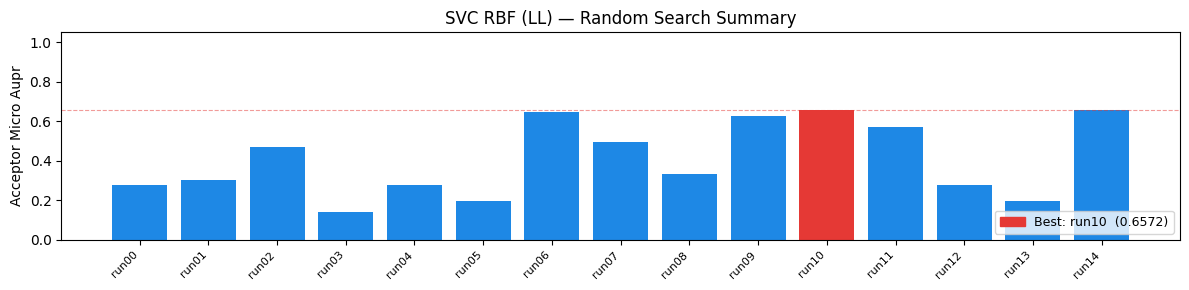

In [ ]:
#RUN STATS
fig = pf.plot_search_summary(
    svc_ll_df,
    title="SVC RBF (LL) — Random Search Summary"
)
plt.show()

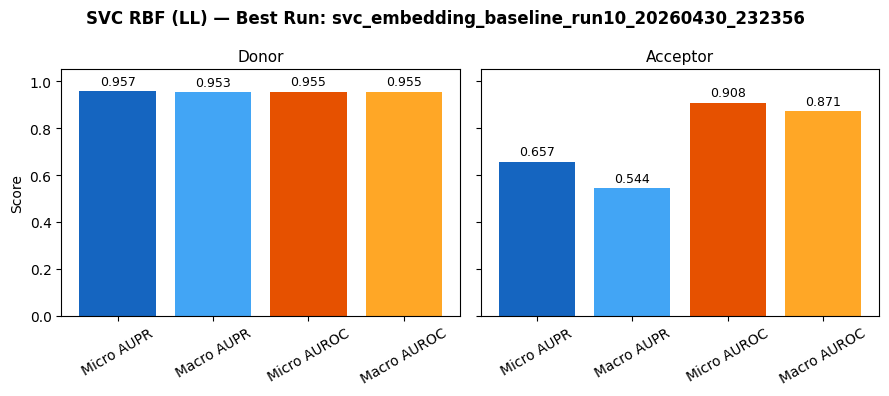

In [ ]:
#RUN STATS
fig = pf.plot_best_run_metrics(
    donor_vals={m: best_svc_ll[f"donor_{m}"] for m in pf.METRIC_COLS},
    acceptor_vals={m: best_svc_ll[f"acceptor_{m}"] for m in pf.METRIC_COLS},
    title=f"SVC RBF (LL) — Best Run: {best_svc_ll['run_tag']}"
)
plt.show()

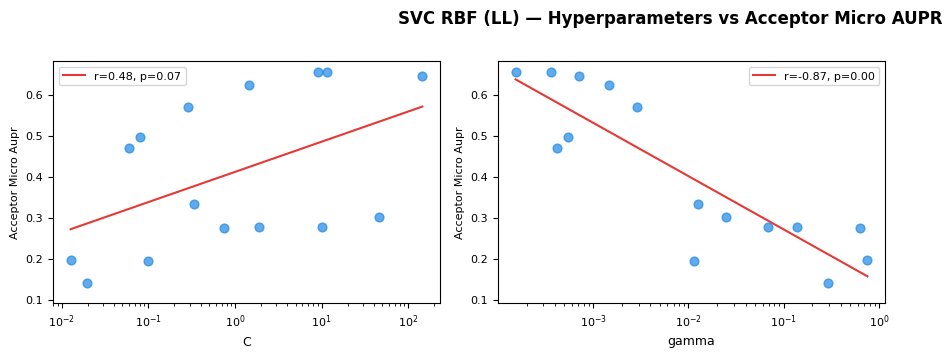

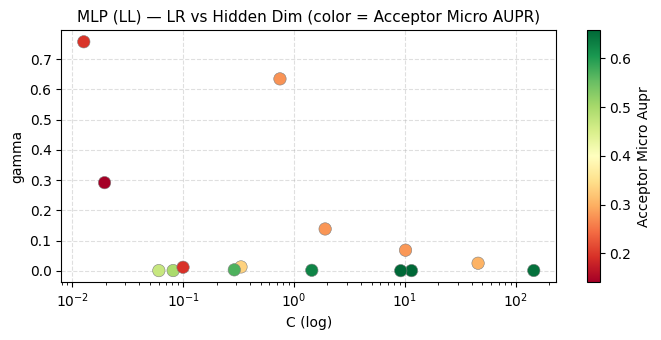

In [ ]:
 #PLOT HYPERPARAMETERS & INTERACTIONS
fig = pf.plot_hyperparam_scatter(
    svc_ll_df,
    param_keys=["C", "gamma"],
    metric="acceptor_micro_aupr",
    log_scale_params=["C", "gamma"],
    title="SVC RBF (LL) — Hyperparameters vs Acceptor Micro AUPR"
)
plt.show()

fig = pf.plot_hyperparam_interaction(
    svc_ll_df,
    x_key  = "C",
    y_key  = "gamma",
    x_log  = True,
    metric = "acceptor_micro_aupr",
    title  = "MLP (LL) — LR vs Hidden Dim (color = Acceptor Micro AUPR)",
)
plt.show()

###3.9: Comparison Figure

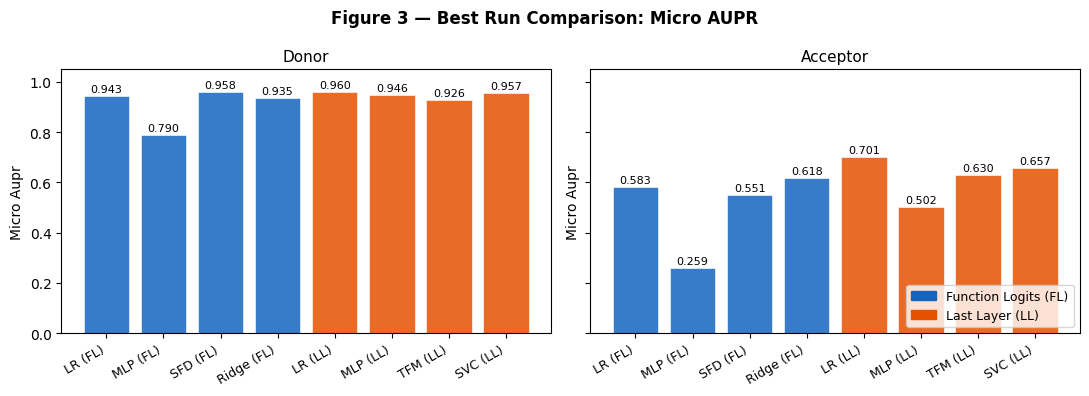

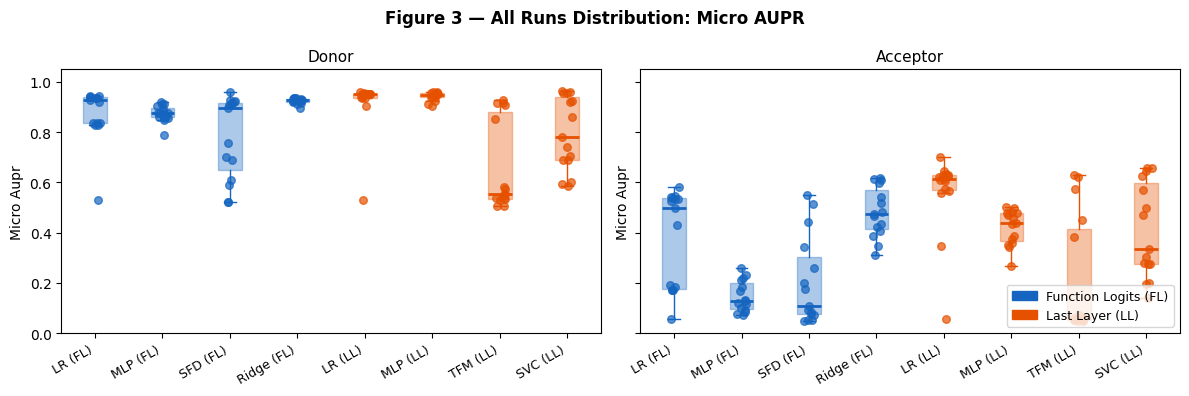

In [ ]:
importlib.reload(pf)

entries = [
    ("LR (FL)",    "fl", best_lr_fl),
    ("MLP (FL)",   "fl", best_mlp_fl),
    ("SFD (FL)",   "fl", best_sfd_fl),
    ("Ridge (FL)", "fl", best_ridge_fl),
    ("LR (LL)",    "ll", best_lr_ll),
    ("MLP (LL)",   "ll", best_mlp_ll),
    ("TFM (LL)",   "ll", best_tfm_ll),
    ("SVC (LL)",   "ll", best_svc_ll),
]

fig = pf.plot_comparison_best(entries, title="Figure 3 — Best Run Comparison: Micro AUPR")
plt.show()

dist_entries = [
    ("LR (FL)",    "fl", lr_fl_df),
    ("MLP (FL)",   "fl", mlp_fl_df),
    ("SFD (FL)",   "fl", sfd_fl_df),
    ("Ridge (FL)", "fl", ridge_fl_df),
    ("LR (LL)",    "ll", lr_ll_df),
    ("MLP (LL)",   "ll", mlp_ll_df),
    ("TFM (LL)",   "ll", tfm_ll_df),
    ("SVC (LL)",   "ll", svc_ll_df),
]

fig = pf.plot_comparison_distribution(dist_entries, title="Figure 3 — All Runs Distribution: Micro AUPR")
plt.show()

#Figure 4: Selected Model(s): FL-Ridge Classifier, LL-?

###4.1: (FL) Ridge Classifier Big & Refined Run

Total runs: 45


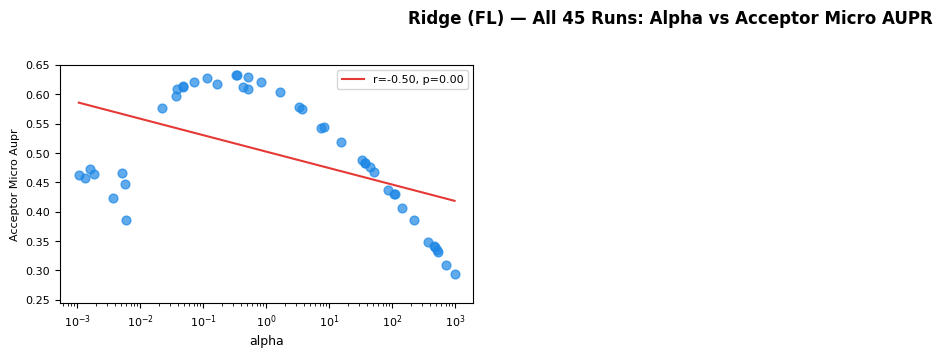

In [ ]:
RS_RUNS_RIDGE_LARGE = [
    "ridge_baseline_large_run00_20260430_222546",
    "ridge_baseline_large_run01_20260430_222944",
    "ridge_baseline_large_run02_20260430_223010",
    "ridge_baseline_large_run03_20260430_223035",
    "ridge_baseline_large_run04_20260430_223058",
    "ridge_baseline_large_run05_20260430_223119",
    "ridge_baseline_large_run06_20260430_223139",
    "ridge_baseline_large_run07_20260430_223203",
    "ridge_baseline_large_run08_20260430_223224",
    "ridge_baseline_large_run09_20260430_223247",
    "ridge_baseline_large_run10_20260430_223309",
    "ridge_baseline_large_run11_20260430_223332",
    "ridge_baseline_large_run12_20260430_223353",
    "ridge_baseline_large_run13_20260430_223417",
    "ridge_baseline_large_run14_20260430_223437",
    "ridge_baseline_large_run15_20260430_223503",
    "ridge_baseline_large_run16_20260430_223529",
    "ridge_baseline_large_run17_20260430_223551",
    "ridge_baseline_large_run18_20260430_223616",
    "ridge_baseline_large_run19_20260430_223637",
    "ridge_baseline_large_run20_20260430_223701",
    "ridge_baseline_large_run21_20260430_223721",
    "ridge_baseline_large_run22_20260430_223750",
    "ridge_baseline_large_run23_20260430_223816",
    "ridge_baseline_large_run24_20260430_223835",
    "ridge_baseline_large_run25_20260430_223859",
    "ridge_baseline_large_run26_20260430_223923",
    "ridge_baseline_large_run27_20260430_223951",
    "ridge_baseline_large_run28_20260430_224016",
    "ridge_baseline_large_run29_20260430_224043",
]

RS_RUNS_RIDGE_ALL = RS_RUNS_RIDGE_FL + RS_RUNS_RIDGE_LARGE

ridge_all_df = pf.load_random_search_results(
    ML_DIR / "results", "ridge_baseline", "BAHD"
)
ridge_all_df = ridge_all_df[
    ridge_all_df["run_tag"].isin(RS_RUNS_RIDGE_ALL)
].reset_index(drop=True)

print(f"Total runs: {len(ridge_all_df)}")

fig = pf.plot_hyperparam_scatter(
    ridge_all_df,
    param_keys=["alpha"],
    metric="acceptor_micro_aupr",
    log_scale_params=["alpha"],
    title="Ridge (FL) — All 45 Runs: Alpha vs Acceptor Micro AUPR"
)
plt.show()

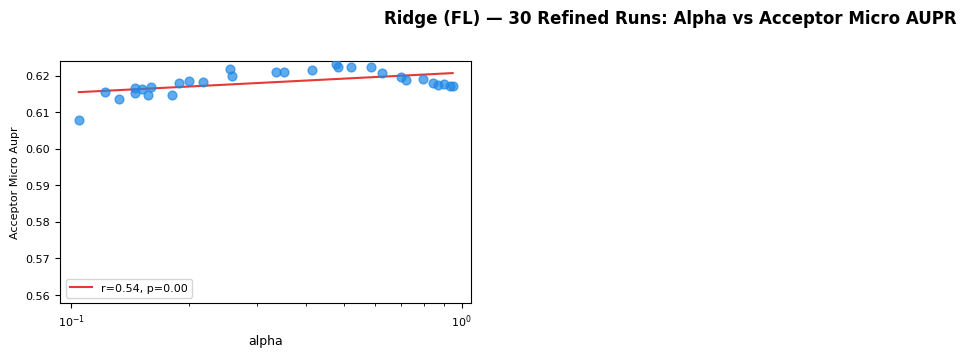

  BEST REFINED RIDGE (FL) RUN
  Run tag         : ridge_baseline_refined_run08_20260430_225641
  Alpha           : 0.47612701
  Acceptor AUPR   : 0.6232
  Donor    AUPR   : 0.9434


In [ ]:
RS_RUNS_RIDGE_REFINED = [
    "ridge_baseline_refined_run00_20260430_225328",
    "ridge_baseline_refined_run01_20260430_225352",
    "ridge_baseline_refined_run02_20260430_225418",
    "ridge_baseline_refined_run03_20260430_225441",
    "ridge_baseline_refined_run04_20260430_225506",
    "ridge_baseline_refined_run05_20260430_225530",
    "ridge_baseline_refined_run06_20260430_225553",
    "ridge_baseline_refined_run07_20260430_225618",
    "ridge_baseline_refined_run08_20260430_225641",
    "ridge_baseline_refined_run09_20260430_225706",
    "ridge_baseline_refined_run10_20260430_225728",
    "ridge_baseline_refined_run11_20260430_225751",
    "ridge_baseline_refined_run12_20260430_225816",
    "ridge_baseline_refined_run13_20260430_225852",
    "ridge_baseline_refined_run14_20260430_225913",
    "ridge_baseline_refined_run15_20260430_225937",
    "ridge_baseline_refined_run16_20260430_225958",
    "ridge_baseline_refined_run17_20260430_230023",
    "ridge_baseline_refined_run18_20260430_230046",
    "ridge_baseline_refined_run19_20260430_230111",
    "ridge_baseline_refined_run20_20260430_230135",
    "ridge_baseline_refined_run21_20260430_230156",
    "ridge_baseline_refined_run22_20260430_230221",
    "ridge_baseline_refined_run23_20260430_230241",
    "ridge_baseline_refined_run24_20260430_230306",
    "ridge_baseline_refined_run25_20260430_230328",
    "ridge_baseline_refined_run26_20260430_230353",
    "ridge_baseline_refined_run27_20260430_230417",
    "ridge_baseline_refined_run28_20260430_230440",
    "ridge_baseline_refined_run29_20260430_230500",
]

ridge_refined_df = pf.load_random_search_results(
    ML_DIR / "results", "ridge_baseline", "BAHD"
)
ridge_refined_df = ridge_refined_df[
    ridge_refined_df["run_tag"].isin(RS_RUNS_RIDGE_REFINED)
].reset_index(drop=True)

fig = pf.plot_hyperparam_scatter(
    ridge_refined_df,
    param_keys=["alpha"],
    metric="acceptor_micro_aupr",
    log_scale_params=["alpha"],
    title="Ridge (FL) — 30 Refined Runs: Alpha vs Acceptor Micro AUPR"
)
plt.show()

best_refined = pf.find_best_run(ridge_refined_df, key="acceptor_micro_aupr")

print("=" * 50)
print("  BEST REFINED RIDGE (FL) RUN")
print("=" * 50)
print(f"  Run tag         : {best_refined['run_tag']}")
print(f"  Alpha           : {best_refined['params']['alpha']:.8f}")
print(f"  Acceptor AUPR   : {best_refined['acceptor_micro_aupr']:.4f}")
print(f"  Donor    AUPR   : {best_refined['donor_micro_aupr']:.4f}")
print("=" * 50)

In [ ]:
#FINAL SELECTED PARAMETERS
#ALPHS: 0.47612701

###4.2: (LL) Logistic Regression Big & Refined Run

Total runs loaded: 45


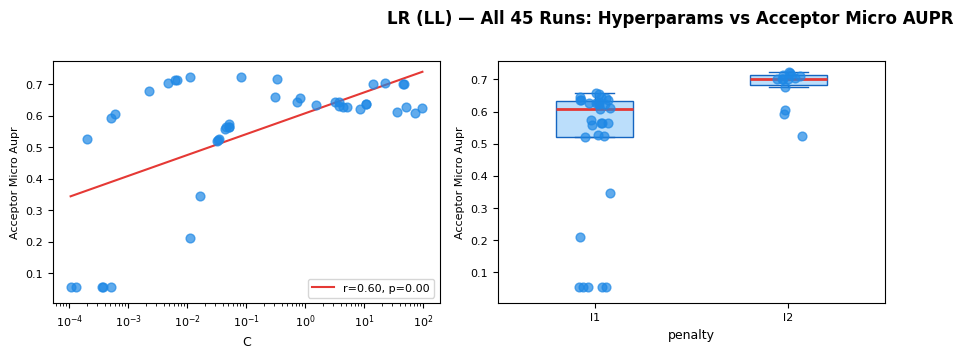

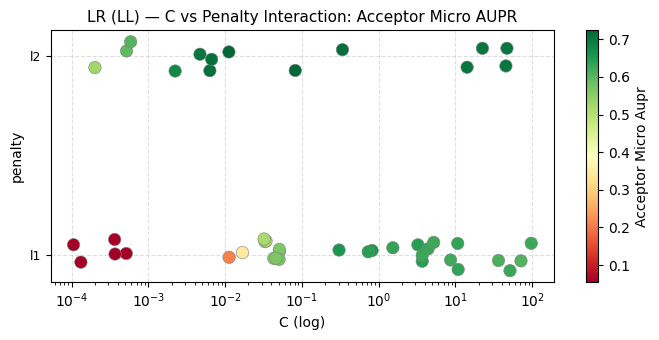

In [ ]:
RS_RUNS_LR_LL_LARGE = [
    "lr_embedding_baseline_large_run00_20260501_011458",
    "lr_embedding_baseline_large_run01_20260501_011607",
    "lr_embedding_baseline_large_run02_20260501_011621",
    "lr_embedding_baseline_large_run03_20260501_011645",
    "lr_embedding_baseline_large_run04_20260501_011706",
    "lr_embedding_baseline_large_run05_20260501_011727",
    "lr_embedding_baseline_large_run06_20260501_011745",
    "lr_embedding_baseline_large_run07_20260501_011803",
    "lr_embedding_baseline_large_run08_20260501_011850",
    "lr_embedding_baseline_large_run09_20260501_011913",
    "lr_embedding_baseline_large_run10_20260501_011930",
    "lr_embedding_baseline_large_run11_20260501_011945",
    "lr_embedding_baseline_large_run12_20260501_012016",
    "lr_embedding_baseline_large_run13_20260501_012038",
    "lr_embedding_baseline_large_run14_20260501_012112",
    "lr_embedding_baseline_large_run15_20260501_012159",
    "lr_embedding_baseline_large_run16_20260501_012246",
    "lr_embedding_baseline_large_run17_20260501_012324",
    "lr_embedding_baseline_large_run18_20260501_012338",
    "lr_embedding_baseline_large_run19_20260501_012359",
    "lr_embedding_baseline_large_run20_20260501_012416",
    "lr_embedding_baseline_large_run21_20260501_012439",
    "lr_embedding_baseline_large_run22_20260501_012456",
    "lr_embedding_baseline_large_run23_20260501_012513",
    "lr_embedding_baseline_large_run24_20260501_012531",
    "lr_embedding_baseline_large_run25_20260501_012556",
    "lr_embedding_baseline_large_run26_20260501_012620",
    "lr_embedding_baseline_large_run27_20260501_012637",
    "lr_embedding_baseline_large_run28_20260501_012651",
    "lr_embedding_baseline_large_run29_20260501_012728",
]

RS_RUNS_LR_LL_ALL = RS_RUNS_LR_LL + RS_RUNS_LR_LL_LARGE

importlib.reload(pf)

lr_ll_all_df = pf.load_random_search_results(
    ML_DIR / "results", "lr_embedding_baseline", "BAHD"
)
lr_ll_all_df = lr_ll_all_df[
    lr_ll_all_df["run_tag"].isin(RS_RUNS_LR_LL_ALL)
].reset_index(drop=True)

print(f"Total runs loaded: {len(lr_ll_all_df)}")

fig = pf.plot_hyperparam_scatter(
    lr_ll_all_df,
    param_keys=["C", "penalty"],
    metric="acceptor_micro_aupr",
    log_scale_params=["C"],
    categorical_params=["penalty"],
    title="LR (LL) — All 45 Runs: Hyperparams vs Acceptor Micro AUPR"
)
plt.show()

fig = pf.plot_hyperparam_interaction(
    lr_ll_all_df,
    x_key="C",
    y_key="penalty",
    metric="acceptor_micro_aupr",
    x_log=True,
    y_categorical=True,
    title="LR (LL) — C vs Penalty Interaction: Acceptor Micro AUPR"
)
plt.show()

In [ ]:
RS_RUNS_LR_LL_REFINED = [
    "lr_ll_refined_run00_20260501_122848",
    "lr_ll_refined_run01_20260501_122954",
    "lr_ll_refined_run02_20260501_123029",
    "lr_ll_refined_run03_20260501_123103",
    "lr_ll_refined_run04_20260501_123145",
    "lr_ll_refined_run05_20260501_123217",
    "lr_ll_refined_run06_20260501_123257",
    "lr_ll_refined_run07_20260501_123331",
    "lr_ll_refined_run08_20260501_123406",
    "lr_ll_refined_run09_20260501_123444",
    "lr_ll_refined_run10_20260501_123521",
    "lr_ll_refined_run11_20260501_123602",
    "lr_ll_refined_run12_20260501_123637",
    "lr_ll_refined_run13_20260501_123717",
    "lr_ll_refined_run14_20260501_123757",
]

RS_RUNS_LR_LL_ALL = RS_RUNS_LR_LL + RS_RUNS_LR_LL_LARGE + RS_RUNS_LR_LL_REFINED

Total runs loaded: 15


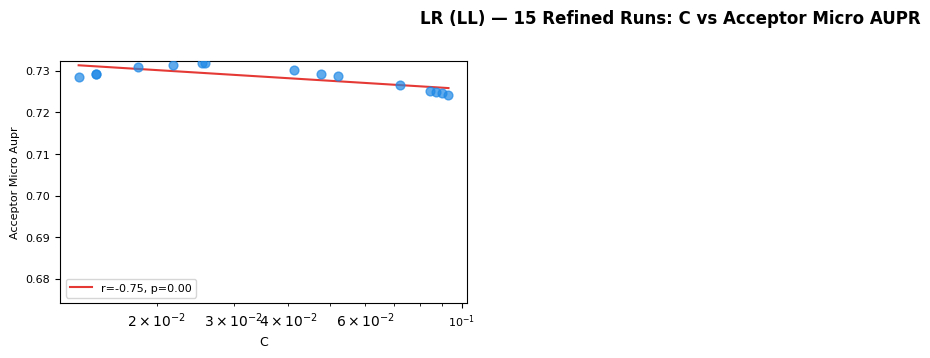

In [ ]:
importlib.reload(pf)

lr_ll_refined_df = pf.load_random_search_results(
    ML_DIR / "results", "lr_embedding_baseline", "BAHD"
)
lr_ll_refined_df = lr_ll_refined_df[
    lr_ll_refined_df["run_tag"].isin(RS_RUNS_LR_LL_REFINED)
].reset_index(drop=True)

print(f"Total runs loaded: {len(lr_ll_refined_df)}")

fig = pf.plot_hyperparam_scatter(
    lr_ll_refined_df,
    param_keys=["C"],
    metric="acceptor_micro_aupr",
    log_scale_params=["C"],
    title="LR (LL) — 15 Refined Runs: C vs Acceptor Micro AUPR"
)
plt.show()

In [ ]:
best_lr_ll = pf.find_best_run(lr_ll_refined_df, key="acceptor_micro_aupr")

print("=" * 50)
print("  BEST LR (LL) RUN")
print("=" * 50)
print(f"  Run tag       : {best_lr_ll['run_tag']}")
print(f"  C             : {best_lr_ll['params'].get('C', 'N/A'):.8f}")
print(f"  Penalty       : {best_lr_ll['params'].get('penalty', 'N/A')}")
print(f"  Acceptor AUPR : {best_lr_ll['acceptor_micro_aupr']:.4f}")
print(f"  Donor    AUPR : {best_lr_ll['donor_micro_aupr']:.4f}")
print("=" * 50)

  BEST LR (LL) RUN
  Run tag       : lr_ll_refined_run11_20260501_123602
  C             : 0.02578700
  Penalty       : l2
  Acceptor AUPR : 0.7320
  Donor    AUPR : 0.9623


###4.3: Comparison Figure

In [12]:
import json, importlib
import paper_figures as pf
importlib.reload(pf)

RESULTS = ML_DIR / "results"

def load_final_metrics(results_subdir, run_tag, dataset="BAHD"):
    run_dir = RESULTS / results_subdir / run_tag
    prefix  = dataset.lower()
    donor   = json.loads((run_dir / f"{prefix}_donor_metrics.json").read_text())["metrics"]
    acceptor= json.loads((run_dir / f"{prefix}_acceptor_metrics.json").read_text())["metrics"]
    return {"donor": donor, "acceptor": acceptor}

RIDGE_5FOLD_TAG  = "ridge_final_5fold_run00_20260501_144618"
RIDGE_LOOCV_TAG  = "ridge_final_loocv_run00_20260501_012800"
LR_5FOLD_TAG     = "lr_ll_final_5fold_run00_20260501_144912"
LR_LOOCV_TAG     = "lr_ll_final_loocv_run00_20260501_125131"

ridge_5fold = load_final_metrics("ridge_baseline",        RIDGE_5FOLD_TAG)
ridge_loocv = load_final_metrics("ridge_baseline",        RIDGE_LOOCV_TAG)
lr_5fold    = load_final_metrics("lr_embedding_baseline", LR_5FOLD_TAG)
lr_loocv    = load_final_metrics("lr_embedding_baseline", LR_LOOCV_TAG)

print("Ridge 5-fold acceptor micro AUPR:", ridge_5fold["acceptor"]["micro_aupr"])
print("Ridge LOOCV  acceptor micro AUPR:", ridge_loocv["acceptor"]["micro_aupr"])
print("LR    5-fold acceptor micro AUPR:", lr_5fold["acceptor"]["micro_aupr"])
print("LR    LOOCV  acceptor micro AUPR:", lr_loocv["acceptor"]["micro_aupr"])
print()
print("Per-fold metrics present (Ridge):", len(ridge_5fold["acceptor"].get("per_fold_metrics", [])), "folds")
print("Per-fold metrics present (LR):   ", len(lr_5fold["acceptor"].get("per_fold_metrics", [])), "folds")

Ridge 5-fold acceptor micro AUPR: 0.6222029527698514
Ridge LOOCV  acceptor micro AUPR: 0.6363627536967184
LR    5-fold acceptor micro AUPR: 0.7355720438302337
LR    LOOCV  acceptor micro AUPR: 0.739446977701921

Per-fold metrics present (Ridge): 5 folds
Per-fold metrics present (LR):    5 folds


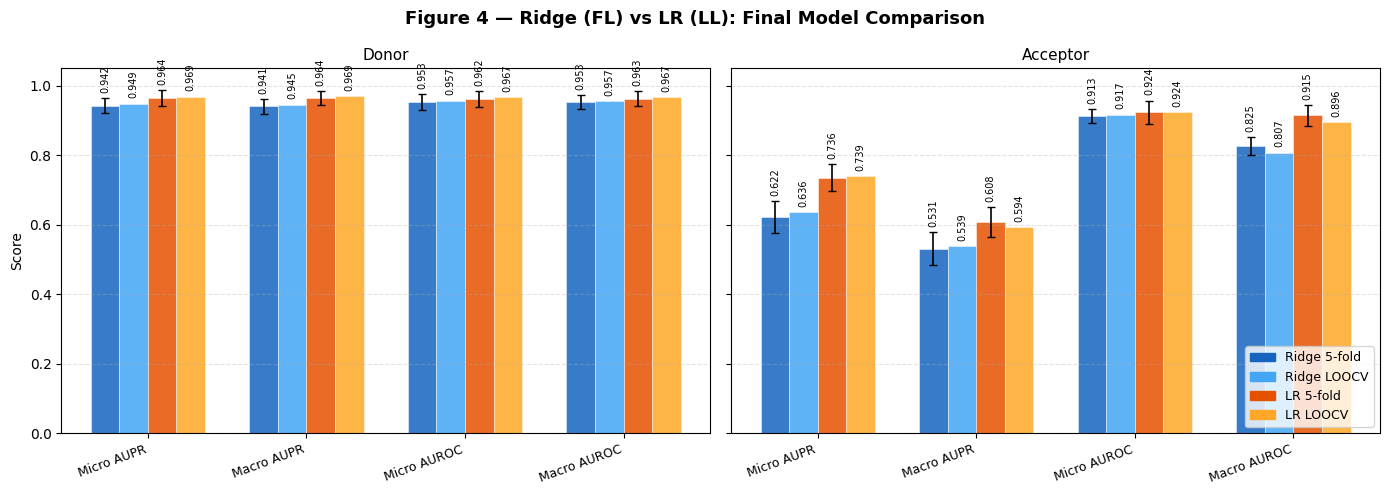

In [13]:
fig = pf.plot_final_comparison(
    ridge_5fold = ridge_5fold,
    ridge_loocv = ridge_loocv,
    lr_5fold    = lr_5fold,
    lr_loocv    = lr_loocv,
    title       = "Figure 4 — Ridge (FL) vs LR (LL): Final Model Comparison",
    figsize     = (14, 5),
)
#fig.savefig(ML_DIR / "figures" / "figure4_final_comparison.pdf", bbox_inches="tight")
#fig.savefig(ML_DIR / "figures" / "figure4_final_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

In [14]:
#check class distribution
import pandas as pd

N_PROTEINS = 366  # total BAHD proteins

def make_support_table(per_label_list, prefix):
    """Build a tidy DataFrame from per_label metrics, stripping the task prefix."""
    rows = []
    for entry in per_label_list:
        name = entry["label"].replace(prefix, "").replace("_", " ").title()
        rows.append({
            "Class": name,
            "N+": int(entry["positive_count"]),
            "Prevalence (%)": round(100 * entry["positive_count"] / N_PROTEINS, 1),
        })
    df = pd.DataFrame(rows).sort_values("N+", ascending=False).reset_index(drop=True)
    df.index += 1  # 1-based row numbers
    return df

# Donor — pull from Ridge (FL) 5-fold result (same label set for all models)
donor_per_label    = ridge_5fold["donor"]["per_label"]
acceptor_per_label = ridge_5fold["acceptor"]["per_label"]

donor_df    = make_support_table(donor_per_label,    prefix="donor_type::")
acceptor_df = make_support_table(acceptor_per_label, prefix="acceptor_superclass::")

print(f"Donor classes  ({len(donor_df)} total, N_proteins={N_PROTEINS})")
print(donor_df.to_string())
print()
print(f"Acceptor classes  ({len(acceptor_df)} total, N_proteins={N_PROTEINS})")
print(acceptor_df.to_string())

Donor classes  (2 total, N_proteins=366)
       Class   N+  Prevalence (%)
1   Aromatic  213            58.2
2  Aliphatic  175            47.8

Acceptor classes  (23 total, N_proteins=366)
                         Class  N+  Prevalence (%)
1       Phenolic Acids (C6-C1)  78            21.3
2          Ornithine Alkaloids  43            11.7
3                   Flavonoids  42            11.5
4     Phenylpropanoids (C6-C3)  40            10.9
5                  Fatty Acyls  38            10.4
6              Pseudoalkaloids  28             7.7
7               Monoterpenoids  22             6.0
8      Phenylethanoids (C6-C2)  21             5.7
9               Small Peptides  21             5.7
10                Naphthalenes  19             5.2
11                Diterpenoids  17             4.6
12  Fatty Acids And Conjugates  16             4.4
13        Tryptophan Alkaloids  15             4.1
14          Tyrosine Alkaloids  14             3.8
15               Isoflavonoids  12            

#Figure 5: UGT Testing Results

In [4]:
#LOAD PACKAGES, PATHS, AND DATASETS
from pathlib import Path
import os, sys, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import torch

ML_DIR        = Path("/content/drive/MyDrive/CS_5782_Final_Project/code_and_data")
RESULTS_DIR   = ML_DIR / "results"
BAHD_DIR      = ML_DIR / "BAHD_dataset"
UGT_DIR       = ML_DIR / "UGT_dataset"
UGT_EMBED_DIR = ML_DIR / "UGT_lastLayer_embeddings"

for p in [ML_DIR, BAHD_DIR, UGT_DIR, UGT_EMBED_DIR]:
    assert p.exists(), f"Path not found: {p}"

os.chdir(ML_DIR)
sys.path.insert(0, str(ML_DIR))

import paper_figures as pf
importlib.reload(pf)

bahd_cache = torch.load(BAHD_DIR / "labels.pt", map_location="cpu")
ugt_cache  = torch.load(UGT_DIR  / "labels.pt", map_location="cpu")

print("Setup complete.")
print(f"  BAHD proteins : {len(bahd_cache['fasta_ids'])}")
print(f"  UGT  proteins : {len(ugt_cache['fasta_ids'])}")
print(f"  UGT  embeddings on disk: {len(list(UGT_EMBED_DIR.glob('*_hidden_layer_steps10.pt')))}")

Setup complete.
  BAHD proteins : 366
  UGT  proteins : 482
  UGT  embeddings on disk: 943


In [5]:
#GET UGT EMBEDDINGS, CHECK FOR MATCHING, AND PREPARE TEST DATASET
import train_lr_embedding_baseline as tr
importlib.reload(tr)

# Drop the 4 proteins with no embedding on disk
embed_stems = {f.stem.replace("_hidden_layer_steps10", "")
               for f in UGT_EMBED_DIR.glob("*_hidden_layer_steps10.pt")}

fasta_ids  = list(ugt_cache["fasta_ids"])
enzyme_ids = list(ugt_cache["enzyme_ids"])
keep       = [i for i, (fid, eid) in enumerate(zip(fasta_ids, enzyme_ids))
              if str(fid) in embed_stems or str(eid) in embed_stems]
n_orig = len(fasta_ids)

# Filter every per-protein field in the cache
ugt_cache_filtered = {}
for k, v in ugt_cache.items():
    if isinstance(v, torch.Tensor) and v.shape[0] == n_orig:
        ugt_cache_filtered[k] = v[keep]
    elif isinstance(v, list) and len(v) == n_orig:
        ugt_cache_filtered[k] = [v[i] for i in keep]
    else:
        ugt_cache_filtered[k] = v

print(f"UGT proteins: {n_orig} → {len(keep)} after dropping {n_orig - len(keep)} unembedded")

# Build mean-pooled feature matrix
print("Building feature matrix...")
X_ugt, ugt_embed_paths, ugt_embed_shapes, match_key = tr.build_embedding_feature_matrix(
    dataset_dir    = UGT_DIR,
    embedding_dir  = UGT_EMBED_DIR,
    cache          = ugt_cache_filtered,
    embedding_glob = "*_hidden_layer_steps10.pt",
    device         = "cpu",
)
print(f"X_ugt shape: {X_ugt.shape}  (proteins × features)")

UGT proteins: 482 → 478 after dropping 4 unembedded
Building feature matrix...
X_ugt shape: (478, 1536)  (proteins × features)


In [6]:
#LOAD MODELS, AND FINISH PREPARING UGT DATASET
#NOTE THAT IT WILL TEST ON OVERLAPPING CLASSES
from utils import get_task_definition, filter_labels_by_support
from sklearn.metrics import average_precision_score, roc_auc_score

LR_FULL_TAG   = "lr_ll_final_full_run00_20260509_201316"
model_run_dir = RESULTS_DIR / "lr_embedding_baseline" / LR_FULL_TAG

with open(model_run_dir / "bahd_acceptor_models.pkl", "rb") as f:
    acceptor_bundle = pickle.load(f)

# UGT acceptor ground truth
y_ugt_all, ugt_acceptor_names = get_task_definition(ugt_cache_filtered, "acceptor")

# Shared labels: must be in BAHD model AND in UGT label space
bahd_model_labels = set(acceptor_bundle["label_names"])
ugt_label_set     = set(ugt_acceptor_names)
ugt_name_to_col   = {name: i for i, name in enumerate(ugt_acceptor_names)}

eval_labels  = sorted(bahd_model_labels & ugt_label_set)
shared_cols  = [ugt_name_to_col[l] for l in eval_labels]
y_ugt_shared = y_ugt_all[:, shared_cols]

# Drop labels with fewer than 2 positives in UGT
y_ugt_shared, eval_labels, ugt_counts = filter_labels_by_support(
    y_ugt_shared, eval_labels, min_positive_count=2
)

print(f"BAHD model labels        : {len(bahd_model_labels)}")
print(f"UGT acceptor labels      : {len(ugt_label_set)}")
print(f"Shared + evaluatable (≥2 UGT positives): {len(eval_labels)}")
print(f"\n{'Label':<50} {'UGT positives':>13}")
print("-" * 65)
for label in eval_labels:
    print(f"  {label:<48} {ugt_counts[label]:>13}")

BAHD model labels        : 23
UGT acceptor labels      : 38
Shared + evaluatable (≥2 UGT positives): 20

Label                                              UGT positives
-----------------------------------------------------------------
  acceptor_superclass::Coumarins                              19
  acceptor_superclass::Cyclic polyketides                      3
  acceptor_superclass::Diterpenoids                            7
  acceptor_superclass::Fatty Acids and Conjugates              3
  acceptor_superclass::Fatty acyls                             9
  acceptor_superclass::Flavonoids                            203
  acceptor_superclass::Isoflavonoids                          48
  acceptor_superclass::Lignans                                10
  acceptor_superclass::Monoterpenoids                         24
  acceptor_superclass::Naphthalenes                           15
  acceptor_superclass::Phenolic acids (C6-C1)                 39
  acceptor_superclass::Phenylethanoids (C6-C2)   

In [7]:
#EVALUATE MODEL PERFORMANCE ON TEST SET
#define some helpers
def safe_aupr(y_true, y_score):
    if y_true.sum() == 0: return None
    v = float(average_precision_score(y_true, y_score))
    return v if np.isfinite(v) else None

def safe_auroc(y_true, y_score):
    if len(np.unique(y_true)) < 2: return None
    v = float(roc_auc_score(y_true, y_score))
    return v if np.isfinite(v) else None

# Score each shared label with the BAHD-trained classifier
n_labels     = len(eval_labels)
score_matrix = np.zeros((X_ugt.shape[0], n_labels), dtype=np.float32)

for col_idx, label in enumerate(eval_labels):
    model = acceptor_bundle["models"][label]
    if model["mode"] == "constant":
        score_matrix[:, col_idx] = float(model["constant"])
    else:
        score_matrix[:, col_idx] = model["pipeline"].decision_function(X_ugt)

# Per-label metrics
aupr_vals, auroc_vals = [], []
per_label_results = []
for i, label in enumerate(eval_labels):
    y_true  = y_ugt_shared[:, i]
    y_score = score_matrix[:, i]
    aupr    = safe_aupr(y_true, y_score)
    auroc   = safe_auroc(y_true, y_score)
    if aupr  is not None: aupr_vals.append(aupr)
    if auroc is not None: auroc_vals.append(auroc)
    per_label_results.append({"label": label, "n_pos": int(y_true.sum()),
                               "aupr": aupr, "auroc": auroc})

# Aggregate
micro_aupr  = safe_aupr( y_ugt_shared.reshape(-1), score_matrix.reshape(-1))
micro_auroc = safe_auroc(y_ugt_shared.reshape(-1), score_matrix.reshape(-1))
macro_aupr  = float(np.mean(aupr_vals))  if aupr_vals  else None
macro_auroc = float(np.mean(auroc_vals)) if auroc_vals else None

print(f"UGT held-out evaluation — BAHD-trained LR (LL), {len(eval_labels)} shared acceptor labels")
print(f"  Micro AUPR  : {micro_aupr:.4f}")
print(f"  Macro AUPR  : {macro_aupr:.4f}")
print(f"  Micro AUROC : {micro_auroc:.4f}")
print(f"  Macro AUROC : {macro_auroc:.4f}")
print()
print(f"{'Label':<45} {'N+':>4}  {'AUPR':>6}  {'AUROC':>6}")
print("-" * 65)
for r in sorted(per_label_results, key=lambda x: -(x["aupr"] or 0)):
    aupr_s  = f"{r['aupr']:.4f}"  if r["aupr"]  is not None else "  N/A"
    auroc_s = f"{r['auroc']:.4f}" if r["auroc"] is not None else "  N/A"
    print(f"  {r['label']:<43} {r['n_pos']:>4}  {aupr_s:>6}  {auroc_s:>6}")

UGT held-out evaluation — BAHD-trained LR (LL), 20 shared acceptor labels
  Micro AUPR  : 0.1296
  Macro AUPR  : 0.0706
  Micro AUROC : 0.6696
  Macro AUROC : 0.5376

Label                                           N+    AUPR   AUROC
-----------------------------------------------------------------
  acceptor_superclass::Flavonoids              203  0.3813  0.4800
  acceptor_superclass::Triterpenoids            37  0.1371  0.6621
  acceptor_superclass::Saccharides              13  0.1213  0.7348
  acceptor_superclass::Phenylpropanoids (C6-C3)   36  0.1092  0.6306
  acceptor_superclass::Phenolic acids (C6-C1)   39  0.1072  0.5783
  acceptor_superclass::Isoflavonoids            48  0.0886  0.4722
  acceptor_superclass::Monoterpenoids           24  0.0856  0.6228
  acceptor_superclass::Coumarins                19  0.0598  0.5535
  acceptor_superclass::Diterpenoids              7  0.0525  0.6093
  acceptor_superclass::Tryptophan alkaloids     16  0.0428  0.5652
  acceptor_superclass::Napht

In [8]:
#GATHER OTHER INFO FOR FIGURE
import json

def load_final_metrics(results_subdir, run_tag, dataset="BAHD"):
    run_dir = RESULTS_DIR / results_subdir / run_tag
    prefix  = dataset.lower()
    donor   = json.loads((run_dir / f"{prefix}_donor_metrics.json").read_text())["metrics"]
    acceptor= json.loads((run_dir / f"{prefix}_acceptor_metrics.json").read_text())["metrics"]
    return {"donor": donor, "acceptor": acceptor}

LR_5FOLD_TAG = "lr_ll_final_5fold_run00_20260501_144912"
LR_LOOCV_TAG = "lr_ll_final_loocv_run00_20260501_125131"

lr_5fold = load_final_metrics("lr_embedding_baseline", LR_5FOLD_TAG)
lr_loocv = load_final_metrics("lr_embedding_baseline", LR_LOOCV_TAG)

print("LR 5-fold acceptor micro AUPR:", lr_5fold["acceptor"]["micro_aupr"])
print("LR LOOCV  acceptor micro AUPR:", lr_loocv["acceptor"]["micro_aupr"])

LR 5-fold acceptor micro AUPR: 0.7355720438302337
LR LOOCV  acceptor micro AUPR: 0.739446977701921


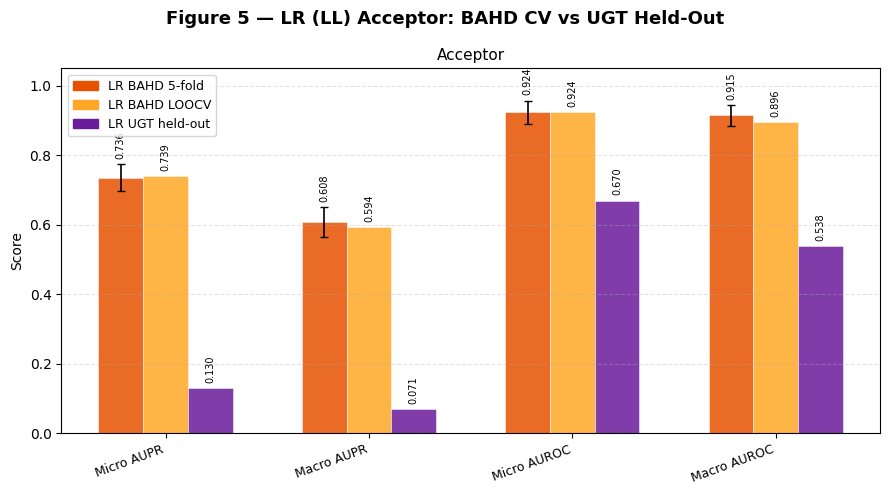

In [9]:
#GENERATE AND SAVE FIGURE
importlib.reload(pf)

ugt_metrics = {
    "micro_aupr":  micro_aupr,
    "macro_aupr":  macro_aupr,
    "micro_auroc": micro_auroc,
    "macro_auroc": macro_auroc,
}

fig = pf.plot_ugt_generalization(
    lr_5fold    = lr_5fold,
    lr_loocv    = lr_loocv,
    ugt_metrics = ugt_metrics,
    title       = "Figure 5 — LR (LL) Acceptor: BAHD CV vs UGT Held-Out",
    figsize     = (9, 5),
)
(ML_DIR / "figures").mkdir(exist_ok=True)
fig.savefig(ML_DIR / "figures" / "figure5_ugt_generalization.pdf", bbox_inches="tight")
fig.savefig(ML_DIR / "figures" / "figure5_ugt_generalization.png", dpi=200, bbox_inches="tight")
plt.show()

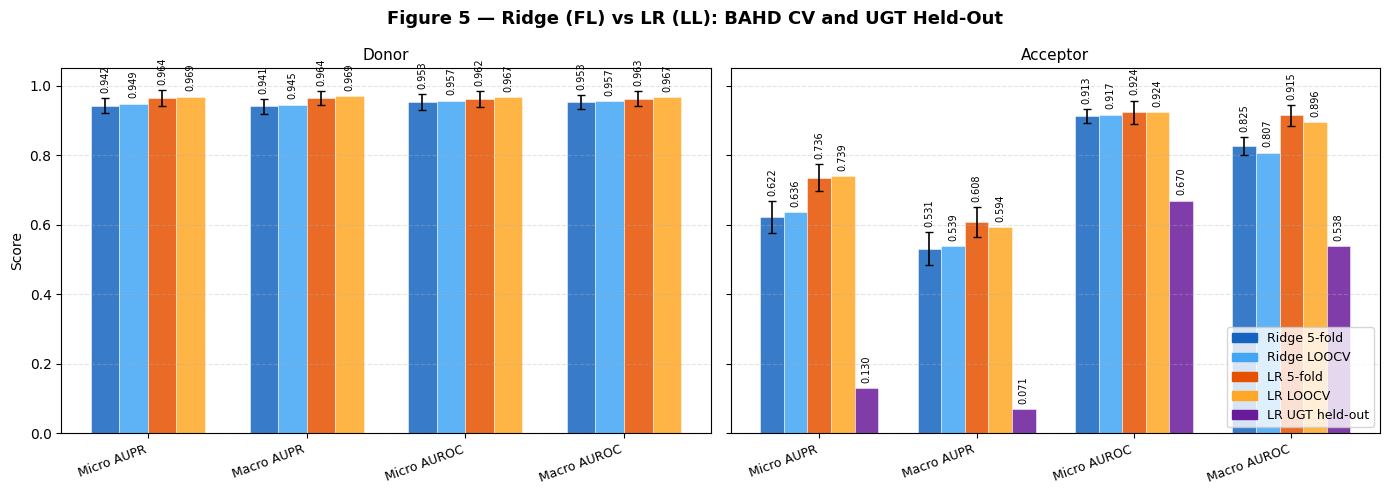

In [15]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

METRIC_COLS   = ["micro_aupr", "macro_aupr", "micro_auroc", "macro_auroc"]
METRIC_LABELS = ["Micro AUPR", "Macro AUPR", "Micro AUROC", "Macro AUROC"]

BAR_COLORS = {
    "ridge_5fold": "#1565C0",
    "ridge_loocv": "#42A5F5",
    "lr_5fold":    "#E65100",
    "lr_loocv":    "#FFA726",
    "ugt":         "#6A1B9A",
}
BAR_LABELS = {
    "ridge_5fold": "Ridge 5-fold",
    "ridge_loocv": "Ridge LOOCV",
    "lr_5fold":    "LR 5-fold",
    "lr_loocv":    "LR LOOCV",
    "ugt":         "LR UGT held-out",
}

ugt_metrics = {
    "micro_aupr":  micro_aupr,
    "macro_aupr":  macro_aupr,
    "micro_auroc": micro_auroc,
    "macro_auroc": macro_auroc,
}

sources = {
    "ridge_5fold": ridge_5fold,
    "ridge_loocv": ridge_loocv,
    "lr_5fold":    lr_5fold,
    "lr_loocv":    lr_loocv,
}

ylim      = (0.0, 1.05)
x         = np.arange(len(METRIC_COLS))
base_order = ["ridge_5fold", "ridge_loocv", "lr_5fold", "lr_loocv"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Figure 5 — Ridge (FL) vs LR (LL): BAHD CV and UGT Held-Out",
             fontsize=13, fontweight="bold")

for ax, task in zip(axes, ["donor", "acceptor"]):
    bar_order = base_order + (["ugt"] if task == "acceptor" else [])
    n_bars    = len(bar_order)
    width     = 0.15 if n_bars == 5 else 0.18

    for bar_i, key in enumerate(bar_order):
        task_m = ugt_metrics if key == "ugt" else sources[key].get(task, {})
        vals   = [task_m.get(m) for m in METRIC_COLS]
        color  = BAR_COLORS[key]

        errs = [None] * len(METRIC_COLS)
        if "5fold" in key:
            pfm = task_m.get("per_fold_metrics", [])
            if pfm:
                for mi, m in enumerate(METRIC_COLS):
                    fold_vals = [f[m] for f in pfm if f.get(m) is not None]
                    if len(fold_vals) >= 2:
                        errs[mi] = float(np.std(fold_vals, ddof=1))

        offset = (bar_i - (n_bars - 1) / 2) * width
        for mi in range(len(METRIC_COLS)):
            val    = vals[mi]
            err    = errs[mi]
            height = float(val) if val is not None else 0.0
            ax.bar(x[mi] + offset, height, width=width,
                   color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
            if val is not None and err is not None:
                ax.errorbar(x[mi] + offset, height, yerr=err,
                            fmt="none", ecolor="black",
                            elinewidth=1.2, capsize=3, zorder=5)
            if val is not None:
                label_y = height + (err if err else 0) + 0.015
                ax.text(x[mi] + offset, min(label_y, ylim[1] - 0.02),
                        f"{height:.3f}", ha="center", va="bottom",
                        fontsize=7, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(METRIC_LABELS, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(ylim)
    ax.set_title(task.capitalize(), fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel("Score")
    ax.grid(axis="y", linestyle="--", alpha=0.35)

legend_keys = base_order + ["ugt"]
axes[1].legend(
    handles=[mpatches.Patch(color=BAR_COLORS[k], label=BAR_LABELS[k]) for k in legend_keys],
    fontsize=9, loc="lower right",
)

plt.tight_layout()
(ML_DIR / "figures").mkdir(exist_ok=True)
fig.savefig(ML_DIR / "figures" / "figure5_final_comparison_ugt.pdf", bbox_inches="tight")
fig.savefig(ML_DIR / "figures" / "figure5_final_comparison_ugt.png", dpi=200, bbox_inches="tight")
plt.show()